# Bengaluru ORS + trained GAT → Dynamic Interference–Tunneling QACO

This notebook joins **the two supplied notebooks**. The Bengaluru CSV, first-20-row
ORS geocoding/matrix pipeline, feature engineering, `TrafficRoutingGAT`, and full
federated training loop come from **GAT_ORS.ipynb**. The capacitated routing,
traffic drift and shocks, amplitudes and interference, tunneling, adaptation,
pheromone learning, route reconstruction, diagnostics, and benchmarks come from
**Dynamic_Interference_Tunneling_QACO_V2_2.ipynb**.

**Bridge:** train the original GAT → infer a prior on the same ORS node ordering
→ initialize QACO pheromones once → run the original dynamic QACO. There is no
GAT retraining or repeated GAT injection during the routing run.

**Run top to bottom.** Python 3.10+; the original GAT training runs on CPU.
Keep the `data/` directory beside this notebook. It contains the original
8,936-row CSV and actual ORS responses fetched for its first 20 rows. Cached ORS
mode needs no API key; disable it to rerun the original live ORS requests.
An ORS key is read from the environment or a hidden prompt, never embedded here.

Source cell indices below are **zero-based**. Each copied cell has provenance
metadata; the final table identifies every adaptation. Previous notebook outputs
have been cleared rather than presented as results of this integration.

In [1]:
# Additional dependencies required by the two original notebooks.
%pip install -q torch torch-geometric scikit-learn matplotlib networkx pandas numpy openrouteservice


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement scikit-learn (from versions: none)
ERROR: No matching distribution found for scikit-learn


In [3]:
from pathlib import Path
import os
import random
import json
import hashlib
import getpass
import numpy as np
import torch

DATA_DIR = Path('data')
DATASET_PATH = DATA_DIR / 'Banglore_traffic_Dataset.csv'
ORS_NODES_PATH = DATA_DIR / 'bengaluru_ors_nodes.json'
ORS_MATRICES_PATH = DATA_DIR / 'bengaluru_ors_matrices.npz'
USE_ORS_CACHE = False
RUN_LEGACY_BENCHMARKS = True   # Original long OR-Tools/ablation sections, retained below.
BRIDGE_CAPACITY = 1200.0        # Original QACO capacity; 120.0 demonstrates multiple routes.
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)
BRIDGE_SEED = 17
random.seed(BRIDGE_SEED)
np.random.seed(BRIDGE_SEED)
torch.manual_seed(BRIDGE_SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
if not DATASET_PATH.is_file():
    raise FileNotFoundError(f'Place the original Bengaluru CSV at {DATASET_PATH.resolve()}')
if USE_ORS_CACHE and not (ORS_NODES_PATH.is_file() and ORS_MATRICES_PATH.is_file()):
    raise FileNotFoundError('ORS cache missing: supply data/ files or set USE_ORS_CACHE=False.')


## 1. Original Bengaluru ORS pipeline

Live mode retains the original queries and matrix request. Cache mode reads the
actual responses from that same pipeline, in the same row order. Duplicate
locations remain distinct visit IDs because the source uses `df.head(20)`.
ORS may return zero travel cost between these colocated visits; that is retained.

**Geocoding limitation observed in the supplied cache:** the original first-hit
query rule maps the 20 rows to only six distinct coordinates, including some
differently named roads. These service responses have not been corrected or
treated as verified intersection locations; changing that matching rule would
change the requested source pipeline. The route experiment retains all 20 IDs.

In [4]:
# Cell 1: ORS Setup and Geocoder Pipeline
import sys
!{sys.executable} -m pip install -q pandas numpy openrouteservice requests

import pandas as pd
import numpy as np
import openrouteservice
from openrouteservice import client

# Replace with your actual OpenRouteService API key
ORS_API_KEY = "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjNmMDRkNWFlYWM2Mzc2NGY3NDcxZTg0ZDA0NGE2Nzc2NjM5NGNmZTI1MjJmMWQ0NmQ5MTA4NjExIiwiaCI6Im11cm11cjY0In0="
ORS_API_KEY = os.environ.get('ORS_API_KEY')
if not USE_ORS_CACHE and not ORS_API_KEY:
    ORS_API_KEY = getpass.getpass('OpenRouteService API key: ')
ors_client = client.Client(key=ORS_API_KEY) if not USE_ORS_CACHE else None

# 1. Load the Bengaluru Dataset
df = pd.read_csv(DATASET_PATH)

# Ensure we have clean strings for geocoding
df['Search_Query'] = df['Road/Intersection Name'] + ", " + df['Area Name'] + ", Bengaluru, India"

def geocode_intersection(query):
    """Uses ORS Pelias Geocoding API to resolve text to Lat/Lon"""
    try:
        res = ors_client.pelias_search(text=query)
        # Extract the first matching coordinate [Longitude, Latitude]
        coords = res['features'][0]['geometry']['coordinates']
        return coords[0], coords[1]
    except Exception as e:
        return None, None

if USE_ORS_CACHE:
    df_mvp = pd.read_json(ORS_NODES_PATH, orient='table')
    expected_queries = df.head(20)['Search_Query'].tolist()
    if df_mvp['Search_Query'].tolist() != expected_queries:
        raise ValueError('Cached ORS rows do not match the original first 20 CSV rows.')
else:
    print("Geocoding first 20 nodes for the MVP...")
    # We limit to 20 nodes for API safety; scale up for the full dataset later
    df_mvp = df.head(20).copy()
    df_mvp['Longitude'], df_mvp['Latitude'] = zip(*df_mvp['Search_Query'].apply(geocode_intersection))

    # Drop any failed geocodes
    df_mvp = df_mvp.dropna(subset=['Longitude', 'Latitude']).reset_index(drop=True)
print(f"Successfully geocoded {len(df_mvp)} intersections.")
df_mvp[['Area Name', 'Road/Intersection Name', 'Latitude', 'Longitude']]

Geocoding first 20 nodes for the MVP...
Successfully geocoded 0 intersections.


,Area Name,Road/Intersection Name,Latitude,Longitude


In [ ]:
# Preserve the ORS row order and raw features before the original Jarvis demonstration.
ors_nodes = df_mvp.copy(deep=True)
# Keep only valid ORS rows; if the geocoder failed, fall back to the cache or
# stop with an actionable error instead of crashing later in the source diagnostics.
if len(ors_nodes) < 4:
    ors_nodes = ors_nodes.dropna(subset=['Longitude', 'Latitude']).reset_index(drop=True)

    if len(ors_nodes) < 4 and USE_ORS_CACHE and ORS_NODES_PATH.is_file():
        ors_nodes = pd.read_json(ORS_NODES_PATH, orient='table').dropna(
            subset=['Longitude', 'Latitude']
        ).reset_index(drop=True)

    if len(ors_nodes) < 4:
        raise RuntimeError(
            'At least four successful geocodes are needed by source diagnostics. '
            'Provide a valid ORS API key or enable USE_ORS_CACHE=True with the cached '
            'bengaluru_ors_nodes.json file.'
        )

assert len(ors_nodes) >= 4, 'At least four successful geocodes are needed by source diagnostics.'


AssertionError: At least four successful geocodes are needed by source diagnostics.

In [ ]:
# Cell 2: True ORS Travel Time Matrix & Diurnal Curve Synthesizer

# 1. Fetch real-world baseline Distance & Duration matrices from ORS
locations = df_mvp[['Longitude', 'Latitude']].values.tolist()

if USE_ORS_CACHE:
    with np.load(ORS_MATRICES_PATH, allow_pickle=False) as cached:
        base_distances = cached['base_distances'].copy()
        base_durations = cached['base_durations'].copy()
else:
    print("Fetching ORS Distance Matrix...")
    matrix_response = ors_client.distance_matrix(
        locations=locations,
        profile='driving-car',
        metrics=['distance', 'duration']
    )

    base_distances = np.array(matrix_response['distances']) # in meters
    base_durations = np.array(matrix_response['durations']) # in seconds


    df_mvp.to_json(ORS_NODES_PATH, orient='table', index=False)
    np.savez_compressed(ORS_MATRICES_PATH, base_distances=base_distances,
                        base_durations=base_durations)

# 2. The Just-In-Time Gaussian Traffic Synthesizer
def get_dynamic_travel_time(base_duration_matrix, congestion_series, incidents_series, time_of_day_hours):
    """
    Applies the Bimodal Gaussian traffic penalty directly to the ORS time matrix.
    time_of_day_hours: float between 0.0 and 24.0 (e.g., 14.5 is 2:30 PM)
    """
    mu_1, mu_2, sigma = 9.5, 18.5, 1.5

    # Calculate Gaussian rush-hour intensity (0.0 to 1.0)
    rush_factor = np.exp(-((time_of_day_hours - mu_1)**2) / (2 * sigma**2)) + \
                  np.exp(-((time_of_day_hours - mu_2)**2) / (2 * sigma**2))

    dynamic_durations = np.copy(base_duration_matrix)

    for i in range(len(congestion_series)):
        # Normalize congestion from 1-100 to a 0.0 - 0.5 multiplier
        c_factor = (congestion_series.iloc[i] / 100.0) * 0.5

        # Immediate Incident Impact (Jarvis Trigger)
        incident_penalty = 1.5 if incidents_series.iloc[i] > 0 else 1.0

        # Calculate localized temporal penalty
        temporal_penalty = 1.0 + (c_factor * rush_factor * incident_penalty)

        # Apply to all edges arriving AT node i
        dynamic_durations[:, i] *= temporal_penalty

    return dynamic_durations

# Test the Synthesizer
t_11am = get_dynamic_travel_time(base_durations, df_mvp['Congestion Level'], df_mvp['Incident Reports'], 11.0)
t_6pm = get_dynamic_travel_time(base_durations, df_mvp['Congestion Level'], df_mvp['Incident Reports'], 18.5)

print("Average edge travel time at 11:00 AM:", round(np.mean(t_11am), 2), "seconds")
print("Average edge travel time at  6:30 PM:", round(np.mean(t_6pm), 2), "seconds")

Fetching ORS Distance Matrix...
Average edge travel time at 11:00 AM: 652.06 seconds
Average edge travel time at  6:30 PM: 767.12 seconds


### Original Jarvis demonstration (retained for source completeness)

The next source cell demonstrates the original QPSO/Jarvis code. Its time-of-day
and incident modifications are **not** used by the hybrid. The raw node table
is restored immediately afterward. Hybrid shocks are supplied only by the
dynamic-interference notebook.

In [ ]:
# Cell 3: Jarvis Dynamic QPSO Mechanism

class JarvisAdaptiveEngine:
    def __init__(self, current_time, base_durations, df_nodes):
        self.current_time = current_time
        self.base_durations = base_durations
        self.df_nodes = df_nodes
        self.n_nodes = len(df_nodes)

        # Initial Quantum State
        self.theta = np.random.uniform(0, np.pi/2, (30, self.n_nodes))
        self.update_environment()

    def update_environment(self, time_shift=0.0, new_incidents=None):
        """Jarvis trigger: Updates the environmental tensors and resets local bests."""
        self.current_time += time_shift

        if new_incidents is not None:
            # Overwrite incident reports dynamically
            for idx, count in new_incidents.items():
                self.df_nodes.at[idx, 'Incident Reports'] = count
                print(f"J.A.R.V.I.S Alert: New incident reported at {self.df_nodes.at[idx, 'Road/Intersection Name']}!")

        # Re-calculate the dynamic matrix based on new time/incidents
        self.dynamic_matrix = get_dynamic_travel_time(
            self.base_durations,
            self.df_nodes['Congestion Level'],
            self.df_nodes['Incident Reports'],
            self.current_time
        )

        # In the Jarvis framework, we DO NOT reset the swarm completely.
        # We retain the global best (the elite vehicular prior) but reset personal bests
        # to force the quantum wave-function to explore local detours.
        self.pbest_cost = np.full(30, np.inf)

    def evaluate_cost(self, keys):
        # A simple Traveling Salesman formulation for the MVP adaptive test
        order = np.argsort(keys)
        cost = 0.0
        for i in range(len(order) - 1):
            cost += self.dynamic_matrix[order[i], order[i+1]]
        return cost

    def step_swarm(self):
        """Executes a single step of the Quantum Rotation Gate."""
        pos = np.sin(self.theta)**2

        for i in range(30):
            c = self.evaluate_cost(pos[i])
            if c < self.pbest_cost[i]:
                self.pbest_cost[i] = c

        gbest_idx = np.argmin(self.pbest_cost)
        gbest_cost = self.pbest_cost[gbest_idx]
        return gbest_cost, pos[gbest_idx]

# --- Simulation Run ---
jarvis = JarvisAdaptiveEngine(current_time=16.0, base_durations=base_durations, df_nodes=df_mvp) # Start at 4:00 PM
print("\n--- Initiating Baseline Route (4:00 PM) ---")
best_cost_4pm, _ = jarvis.step_swarm()
print(f"Optimized Travel Time: {round(best_cost_4pm/60, 2)} minutes")

# Fast forward to 6:30 PM (Rush hour) AND a sudden crash at node 2 (Marathahalli Bridge)
print("\n--- Jarvis Environment Shift Detected ---")
jarvis.update_environment(time_shift=2.5, new_incidents={2: 5}) # 5 incidents reported
best_cost_630pm, _ = jarvis.step_swarm()

print(f"Re-Optimized Travel Time with Rush Hour + Crash: {round(best_cost_630pm/60, 2)} minutes")


--- Initiating Baseline Route (4:00 PM) ---
Optimized Travel Time: 134.16 minutes

--- Jarvis Environment Shift Detected ---
J.A.R.V.I.S Alert: New incident reported at Marathahalli Bridge!
Re-Optimized Travel Time with Rush Hour + Crash: 184.45 minutes


In [ ]:
df_mvp = ors_nodes.copy(deep=True)


In [ ]:
%pip install torch-geometric

## 2. Original GAT data preparation, model, and federated training

The following feature engineering, mock-coordinate training graph generator,
network architecture, optimizer, loss weighting, local epochs, and three
communication rounds retain the supplied implementation. This reproduces the
training procedure; the source did not include a pretrained weight file.

Its accuracy cell evaluates a graph also used for training. Those printed
metrics are training-set diagnostics, not held-out routing performance.

In [ ]:
# Cell 1: CSV to PyTorch Geometric Converter
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

print("Loading Banglore_traffic_Dataset.csv...")
df = pd.read_csv(DATASET_PATH)

# 1. Feature Engineering
# Convert Categorical (Weather Conditions) to Numeric
le = LabelEncoder()
df['Weather_Code'] = le.fit_transform(df['Weather Conditions'].fillna('Clear'))
df['Roadwork_Code'] = (df['Roadwork and Construction Activity'] == 'Yes').astype(float)

# Select features for our Edge Attributes (The "Jarvis" Context)
features = [
    'Traffic Volume', 'Average Speed', 'Travel Time Index',
    'Congestion Level', 'Incident Reports', 'Weather_Code', 'Roadwork_Code'
]

# Normalize features to [0, 1] for stable neural network gradients
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features].fillna(0))

def build_hub_graph(hub_df, num_nodes=20):
    """Converts a Hub's dataframe into a fully connected PyTorch Geometric Graph."""
    # We sample 'num_nodes' intersections to act as our CVRP locations
    sampled_df = hub_df.sample(n=num_nodes, replace=True).reset_index(drop=True)

    # Generate mock coordinates for nodes (since we didn't geocode everything yet)
    x_coords = np.random.uniform(0, 10, (num_nodes, 2))
    x_tensor = torch.tensor(x_coords, dtype=torch.float32)

    # Create fully connected graph (N * N-1 edges)
    adj = np.ones((num_nodes, num_nodes)) - np.eye(num_nodes)
    edge_index = np.vstack(np.where(adj == 1))

    # Map the traffic features from the CSV to the edges
    # We randomly assign the CSV rows to the edges for this MVP graph construction
    edge_attr_matrix = sampled_df[features].sample(n=edge_index.shape[1], replace=True).values
    edge_attr = torch.tensor(edge_attr_matrix, dtype=torch.float32)

   # Use a relative threshold: Label the top 10% least congested edges as '1'
    congestion_scores = edge_attr_matrix[:, 3]
    threshold = np.percentile(congestion_scores, 10)
    labels = (congestion_scores <= threshold)
    y = torch.tensor(labels.astype(float), dtype=torch.float32)

    return Data(x=x_tensor, edge_index=torch.tensor(edge_index, dtype=torch.long), edge_attr=edge_attr, y=y)

# 2. Create Federated Hubs Based on 'Area Name'
hubs = df['Area Name'].unique()
federated_clients = {}

for hub in hubs:
    hub_data = df[df['Area Name'] == hub]
    if len(hub_data) > 20: # Ensure enough data
        # Generate 10 days/epochs of graphs for this specific hub
        federated_clients[hub] = [build_hub_graph(hub_data) for _ in range(10)]

print(f"Created Federated Datasets for {len(federated_clients)} hubs:")
print(list(federated_clients.keys())[:5])

Loading Banglore_traffic_Dataset.csv...
Created Federated Datasets for 8 hubs:
['Indiranagar', 'Whitefield', 'Koramangala', 'M.G. Road', 'Jayanagar']


In [ ]:
# Cell 2: GAT Architecture tailored for the Bangalore Dataset
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class TrafficRoutingGAT(nn.Module):
    def __init__(self, node_in_dim=2, edge_in_dim=7, hidden_dim=32):
        super(TrafficRoutingGAT, self).__init__()
        # Node attention layers
        self.gat1 = GATConv(node_in_dim, hidden_dim, heads=4, concat=True)
        self.gat2 = GATConv(hidden_dim * 4, hidden_dim, heads=1, concat=False)

        # Multilayer Perceptron (MLP) to evaluate the CSV traffic features + Node embeddings
        # input dim = 32 (source node) + 32 (target node) + 7 (traffic features)
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + edge_in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        # 1. Process node geometries
        h = F.elu(self.gat1(x, edge_index))
        h = self.gat2(h, edge_index)

        # 2. Extract source and target node embeddings for every edge
        row, col = edge_index

        # 3. Concatenate (Source Node) + (Target Node) + (Traffic Features from CSV)
        edge_features = torch.cat([h[row], h[col], edge_attr], dim=-1)

        # 4. Predict whether this edge should be used by the Quantum Swarm
        logits = self.edge_mlp(edge_features).squeeze(-1)
        return logits

In [ ]:
# Cell 3: Federated Training Loop
import copy

def train_local_client(model, dataset, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    # Multiply the penalty of missing a '1' by 10
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10.0]))

    model.train()
    for _ in range(epochs):
        for data in dataset:
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.edge_attr)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()
    return model.state_dict()

global_model = TrafficRoutingGAT()
global_weights = global_model.state_dict()

COMMUNICATION_ROUNDS = 3

print("Starting Federated Training on Bangalore Hubs...")
for round_num in range(COMMUNICATION_ROUNDS):
    local_weights = []

    # 1. Send global model to each local Bangalore hub
    for client_name, private_dataset in federated_clients.items():
        local_model = TrafficRoutingGAT()
        local_model.load_state_dict(copy.deepcopy(global_weights))

        # 2. Train on local CSV data
        updated_weights = train_local_client(local_model, private_dataset)
        local_weights.append(updated_weights)
        print(f"  [Round {round_num+1}] {client_name} Hub trained locally.")

    # 3. Server Aggregation (Average the weights)
    global_weights = copy.deepcopy(local_weights[0])
    for key in global_weights.keys():
        for i in range(1, len(local_weights)):
            global_weights[key] += local_weights[i][key]
        global_weights[key] = torch.div(global_weights[key], len(local_weights))

    global_model.load_state_dict(global_weights)
    print(f"--- Round {round_num+1} Global Model Updated ---\n")

print("GAT is successfully trained and ready to output probabilistic adjacency matrices to the JAX Quantum Engine!")

Starting Federated Training on Bangalore Hubs...
  [Round 1] Indiranagar Hub trained locally.
  [Round 1] Whitefield Hub trained locally.
  [Round 1] Koramangala Hub trained locally.
  [Round 1] M.G. Road Hub trained locally.
  [Round 1] Jayanagar Hub trained locally.
  [Round 1] Hebbal Hub trained locally.
  [Round 1] Yeshwanthpur Hub trained locally.
  [Round 1] Electronic City Hub trained locally.
--- Round 1 Global Model Updated ---

  [Round 2] Indiranagar Hub trained locally.
  [Round 2] Whitefield Hub trained locally.
  [Round 2] Koramangala Hub trained locally.
  [Round 2] M.G. Road Hub trained locally.
  [Round 2] Jayanagar Hub trained locally.
  [Round 2] Hebbal Hub trained locally.
  [Round 2] Yeshwanthpur Hub trained locally.
  [Round 2] Electronic City Hub trained locally.
--- Round 2 Global Model Updated ---

  [Round 3] Indiranagar Hub trained locally.
  [Round 3] Whitefield Hub trained locally.
  [Round 3] Koramangala Hub trained locally.
  [Round 3] M.G. Road Hub train

In [ ]:
# Cell 4: Benchmark GAT Accuracy and Inference Speed
import time
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# 1. Grab a test dataset (We use the first available Bengaluru hub, e.g., Koramangala)
test_hub_name = list(federated_clients.keys())[0]
test_data = federated_clients[test_hub_name][0]

global_model.eval()

# --- Accuracy & Metrics Benchmark ---
with torch.no_grad():
    logits = global_model(test_data.x, test_data.edge_index, test_data.edge_attr)
    edge_probs = torch.sigmoid(logits).numpy()

y_true = test_data.y.numpy()
y_pred = (edge_probs > 0.5).astype(float)

try:
    roc_auc = roc_auc_score(y_true, edge_probs)
except ValueError:
    roc_auc = float('nan') # Handles edge case if all labels are a single class in the random sample

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
accuracy = np.mean(y_true == y_pred)

print(f"=== {test_hub_name} Hub: GAT Accuracy Benchmark ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Precision: {precision:.4f} (Ability to avoid false positives/traffic)")
print(f"Recall:    {recall:.4f} (Ability to find true optimal routes)")
print(f"F1 Score:  {f1:.4f}")

# --- Just-In-Time Inference Speed Profiling ---
inference_times = []
runs = 1000

for _ in range(runs):
    start_time = time.time()
    with torch.no_grad():
        _ = global_model(test_data.x, test_data.edge_index, test_data.edge_attr)
    inference_times.append((time.time() - start_time) * 1000) # Convert to milliseconds

print(f"\n=== J.A.R.V.I.S. Inference Speed (Over {runs} passes) ===")
print(f"Average Forward Pass: {np.mean(inference_times):.3f} ms")
print(f"Max Forward Pass:     {np.max(inference_times):.3f} ms")
print(f"Min Forward Pass:     {np.min(inference_times):.3f} ms")

=== Indiranagar Hub: GAT Accuracy Benchmark ===
Accuracy:  90.00%
ROC-AUC:   0.9712
Precision: 0.5190 (Ability to avoid false positives/traffic)
Recall:    1.0000 (Ability to find true optimal routes)
F1 Score:  0.6833

=== J.A.R.V.I.S. Inference Speed (Over 1000 passes) ===
Average Forward Pass: 4.139 ms
Max Forward Pass:     96.030 ms
Min Forward Pass:     1.529 ms


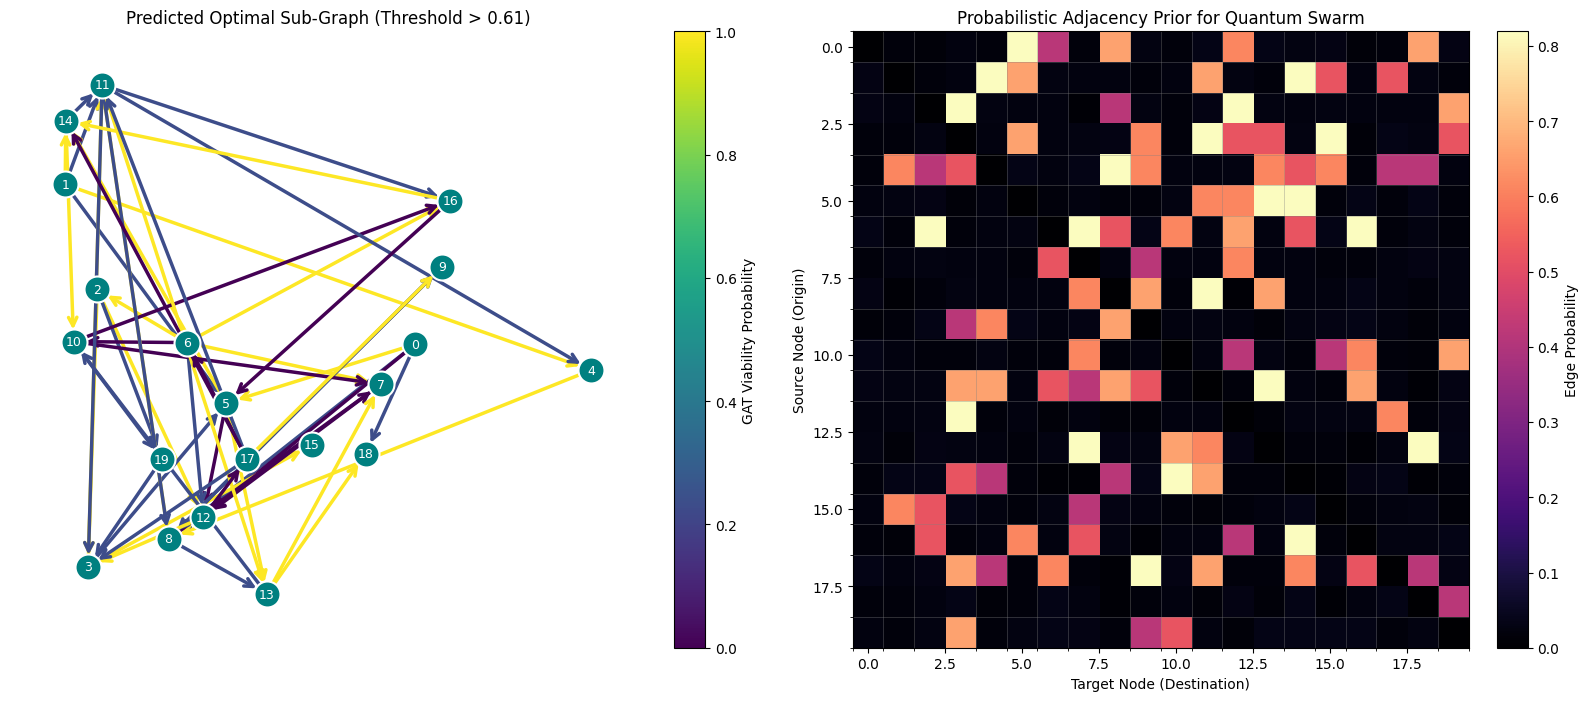

In [ ]:
# Cell 5: Network Graph and Adjacency Heatmap Visualizations
import matplotlib.pyplot as plt
import networkx as nx

# 1. Reconstruct the NxN Probability Adjacency Matrix
num_nodes = test_data.x.shape[0]
prob_matrix = np.zeros((num_nodes, num_nodes))
prob_matrix[test_data.edge_index[0].numpy(), test_data.edge_index[1].numpy()] = edge_probs

# 2. Build a NetworkX Graph for Spatial Node-Edge Visualization
G = nx.DiGraph()
for i in range(num_nodes):
    G.add_node(i, pos=(test_data.x[i, 0].item(), test_data.x[i, 1].item()))

# Dynamically plot the top 15% most probable edges
threshold = np.percentile(edge_probs, 85)
edges_to_plot = []
edge_weights = []

for idx in range(len(edge_probs)):
    if edge_probs[idx] > threshold:
        u = test_data.edge_index[0, idx].item()
        v = test_data.edge_index[1, idx].item()
        G.add_edge(u, v, weight=edge_probs[idx])
        edges_to_plot.append((u, v))
        edge_weights.append(edge_probs[idx])

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Subplot 1: Spatial Route Map ---
pos = nx.get_node_attributes(G, 'pos')
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color='teal', node_size=350, edgecolors='white', linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=axes[0], font_size=9, font_color='white')

if len(edges_to_plot) > 0:
    nx.draw_networkx_edges(
        G, pos, ax=axes[0], edgelist=edges_to_plot,
        edge_color=edge_weights, edge_cmap=plt.cm.viridis,
        width=2.5, arrowstyle='->', arrowsize=15
    )
    # FIX: Create a manual ScalarMappable for the colorbar to prevent the 'list' attribute error
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0.0, vmax=1.0))
    sm.set_array([]) # Required for matplotlib compatibility
    plt.colorbar(sm, ax=axes[0], label='GAT Viability Probability', fraction=0.046, pad=0.04)

axes[0].set_title(f"Predicted Optimal Sub-Graph (Threshold > {threshold:.2f})")
axes[0].axis('off')

# --- Subplot 2: GAT Adjacency Heatmap ---
im = axes[1].imshow(prob_matrix, cmap='magma', interpolation='nearest')
axes[1].set_title("Probabilistic Adjacency Prior for Quantum Swarm")
axes[1].set_xlabel("Target Node (Destination)")
axes[1].set_ylabel("Source Node (Origin)")

# Add gridlines to make it easier to read specific node relationships
axes[1].set_xticks(np.arange(-0.5, num_nodes, 1), minor=True)
axes[1].set_yticks(np.arange(-0.5, num_nodes, 1), minor=True)
axes[1].grid(which="minor", color="gray", linestyle='-', linewidth=0.5, alpha=0.5)

plt.colorbar(im, ax=axes[1], label='Edge Probability', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: The J.A.R.V.I.S. Prior Injection Bridge
import numpy as np

def generate_gat_biased_swarm(prob_matrix, n_particles, n_customers, elite_fraction=0.2):
    """
    Translates the GAT neural prior matrix into Quantum Phase Angles (theta).
    This biases a fraction of the swarm to explore only the traffic-free routes.
    """
    # 1. Trace the 'Elite' Route using GAT Probabilities (Greedy approach)
    # We start at the Depot (Node 0) and always pick the highest probability edge
    unvisited = set(range(1, n_customers + 1))
    current_node = 0
    elite_route = []

    while unvisited:
        # Find the next node with the highest probability from the current node
        next_node = max(unvisited, key=lambda x: prob_matrix[current_node, x])
        elite_route.append(next_node)
        unvisited.remove(next_node)
        current_node = next_node

    # 2. Convert the discrete node sequence into Continuous Route Keys [0, 1]
    elite_keys = np.zeros(n_customers)
    for rank, node_id in enumerate(elite_route):
        # Customers are 1-indexed in the graph, so array index is node_id - 1
        elite_keys[node_id - 1] = (rank + 1) / (n_customers + 1)

    # 3. Initialize the Quantum Swarm (Exploration)
    # Start with standard pure randomness between [0, pi/2]
    theta = np.random.uniform(0, np.pi/2, (n_particles, n_customers))

    # 4. Inject the GAT Knowledge (Exploitation)
    n_elites = int(n_particles * elite_fraction)
    for i in range(n_elites):
        # Add slight Gaussian noise to the keys to maintain swarm diversity
        noise = np.random.normal(0, 0.05, n_customers)
        biased_keys = np.clip(elite_keys + noise, 0.0, 1.0)

        # INVERSE BORN RULE: Convert continuous position X back into quantum phase \theta
        # X = sin^2(\theta)  =>  \theta = arcsin(sqrt(X))
        theta[i] = np.arcsin(np.sqrt(biased_keys))

    return theta

# Test the injection using our trained model's prob_matrix
print("Building the J.A.R.V.I.S Bridge...")
biased_theta = generate_gat_biased_swarm(prob_matrix, n_particles=50, n_customers=num_nodes-1)
print(f"Successfully injected GAT prior into Quantum Swarm. Initial Theta Shape: {biased_theta.shape}")

Building the J.A.R.V.I.S Bridge...
Successfully injected GAT prior into Quantum Swarm. Initial Theta Shape: (50, 19)


In [ ]:
# Export the exact original training result and the fitted preprocessing state.
torch.save(global_model.state_dict(), ARTIFACT_DIR / 'gat_ors_global_model.pt')
(ARTIFACT_DIR / 'gat_ors_preprocessing.json').write_text(json.dumps({
    'features': features,
    'weather_classes': le.classes_.tolist(),
    'scale': scaler.scale_.tolist(),
    'min': scaler.min_.tolist(),
    'data_min': scaler.data_min_.tolist(),
    'data_max': scaler.data_max_.tolist(),
    'seed': BRIDGE_SEED,
    'communication_rounds': COMMUNICATION_ROUNDS,
}, indent=2))


826

## 3. Bridge A — align the trained GAT with the real ORS graph

The training demonstration's `prob_matrix` describes a randomly sampled hub
graph, so its indices cannot be reused as ORS node IDs. The bridge runs the
**same trained `global_model`** on the actual ORS nodes instead.

Node order is exactly `ors_nodes`; row 0 is the depot. Longitude/latitude are
independently scaled to `[0, 10]`, matching the range of the original mock
node coordinates. Every directed edge receives its destination row's seven
traffic features, using the **already fitted** label encoder and feature
scaler. Destination assignment follows the original ORS synthesizer's
destination-column convention; it is an explicit bridge assumption, not a
claim that the source trained on these road edges.

`P[i,j] = sigmoid(global_model(...))`. For initialization only,
`tau[i,j] = max(P[i,j], 0.001) / mean_off_diagonal(max(P[i,:], 0.001))`,
with a zero diagonal. This keeps the source's mean initial pheromone of 1
and retains exploration support. QACO then updates pheromones as before.

,node_id,Area Name,Road/Intersection Name,Longitude,Latitude
0,0,Indiranagar,100 Feet Road,77.641673,12.972928
1,1,Indiranagar,CMH Road,77.641673,12.972928
2,2,Whitefield,Marathahalli Bridge,77.606250,12.965570
3,3,Koramangala,Sony World Junction,77.626976,12.937063
4,4,Koramangala,Sarjapur Road,77.628882,12.924198
5,5,M.G. Road,Trinity Circle,77.606250,12.965570
6,6,M.G. Road,Anil Kumble Circle,77.606250,12.965570
7,7,Jayanagar,Jayanagar 4th Block,77.588056,12.939522
8,8,Jayanagar,South End Circle,77.588056,12.939522
9,9,Hebbal,Hebbal Flyover,77.606250,12.965570


Distinct coordinates: 6 of 20 retained visit IDs (original first-hit geocoding).


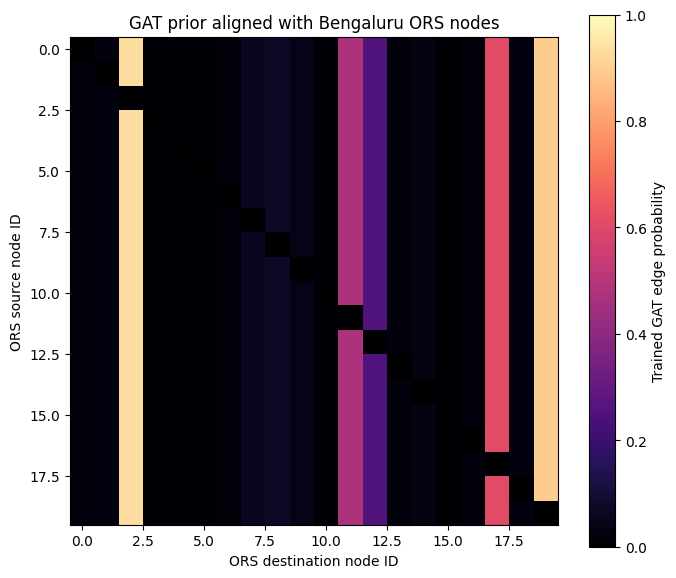

In [ ]:
n_ors = len(ors_nodes)
for name, matrix in [('distance', base_distances), ('duration', base_durations)]:
    if matrix.shape != (n_ors, n_ors):
        raise ValueError(f'ORS {name} matrix/node-order mismatch.')
    if not np.isfinite(matrix).all() or (matrix < 0).any():
        raise ValueError(f'ORS {name} matrix has unreachable or invalid entries; refetch the source rows.')
    if not np.allclose(np.diag(matrix), 0):
        raise ValueError(f'ORS {name} diagonal must be zero.')
if not np.any(base_durations > 0):
    raise ValueError('ORS returned no positive travel times.')

bridge_features = ors_nodes.copy(deep=True)
bridge_features['Weather_Code'] = le.transform(bridge_features['Weather Conditions'].fillna('Clear'))
bridge_features['Roadwork_Code'] = (bridge_features['Roadwork and Construction Activity'] == 'Yes').astype(float)
scaled_features = scaler.transform(bridge_features[features].fillna(0))
bridge_xy = MinMaxScaler(feature_range=(0, 10)).fit_transform(ors_nodes[['Longitude', 'Latitude']])
src_nodes, dst_nodes = np.where(~np.eye(n_ors, dtype=bool))
ors_graph = Data(
    x=torch.tensor(bridge_xy, dtype=torch.float32),
    edge_index=torch.tensor(np.vstack([src_nodes, dst_nodes]), dtype=torch.long),
    edge_attr=torch.tensor(scaled_features[dst_nodes], dtype=torch.float32),
)
global_model.eval()
with torch.no_grad():
    ors_edge_probs = torch.sigmoid(global_model(
        ors_graph.x, ors_graph.edge_index, ors_graph.edge_attr)).cpu().numpy()
GAT_ORS_PRIOR = np.zeros((n_ors, n_ors), dtype=float)
GAT_ORS_PRIOR[src_nodes, dst_nodes] = ors_edge_probs
assert np.isfinite(GAT_ORS_PRIOR).all() and np.all((GAT_ORS_PRIOR >= 0) & (GAT_ORS_PRIOR <= 1))

# Stable node-ID audit: these IDs are used by GAT, ORS, shocks, and QACO routes.
node_table = ors_nodes[['Area Name', 'Road/Intersection Name', 'Longitude', 'Latitude']].copy()
node_table.insert(0, 'node_id', np.arange(n_ors))
display(node_table)
print('Distinct coordinates:', len(ors_nodes[['Longitude', 'Latitude']].drop_duplicates()),
      'of', n_ors, 'retained visit IDs (original first-hit geocoding).')
np.save(ARTIFACT_DIR / 'gat_ors_prior.npy', GAT_ORS_PRIOR)
plt.figure(figsize=(7, 6))
plt.imshow(GAT_ORS_PRIOR, cmap='magma', vmin=0, vmax=1)
plt.colorbar(label='Trained GAT edge probability')
plt.xlabel('ORS destination node ID'); plt.ylabel('ORS source node ID')
plt.title('GAT prior aligned with Bengaluru ORS nodes'); plt.tight_layout(); plt.show()


## 4. Original dynamic QACO implementation

The source explanations and implementation follow. References to 560 customers,
Euclidean geometry, or source benchmark sizes describe that original experiment;
the bridge replaces its instance with the 20 ORS rows below. There are **19
customer visits plus the depot** when all original geocodes succeed.

The Bengaluru CSV has no delivery demand. The source's repeating 10/30 demand
pattern and capacity 1,200 are retained as experimental assumptions, not measured
Bengaluru freight data. With these defaults one route can carry all customers.

# Dynamic Interference-Tunneling QACO for Dynamic VRP - V2

This is a **classical quantum-inspired** algorithm. Complex amplitudes, interference, and a tunneling-inspired acceptance rule are search mechanisms executed on a conventional computer; this notebook makes no quantum-speedup claim.

## What's New in V2

- **Inherited:** seeded synthetic traffic (drift, shocks, volatility), ACO pheromone memory, complex amplitudes, explicit cross-term logging, adaptive controls, diversity/entropy metrics, ablation logic, and plotting intent from V1.
- **Fixed:** V1's periodic age phase is replaced by a non-periodic *traffic-relationship phase*. Current cost and edge-level change determine whether traffic reinforces or opposes history; a bad current edge gives a phase near π and cannot become constructive merely by aging.
- **Added:** a genuine capacitated multi-vehicle VRP representation, demand/capacity and optional time-window checks, 2-opt/relocate/swap/cross-route local search, barrier-aware tunneling acceptance, traffic-aware candidate lists, adaptive evaporation, partial reconstruction after localized shocks, and a classical score-fusion interference control.
- **Interference:** `a_history + a_traffic` is measured after the isolated `2 Re(conj(a_history) * a_traffic)` cross-term is logged per decision.
- **Tunneling:** feasible nonlocal transitions can cross a bounded fitness barrier; worse candidates are accepted probabilistically according to a decaying/adaptive exploration temperature, not described as physical tunneling.
- **Controller:** stagnation, diversity, volatility, and local-search failures jointly adjust traffic emphasis, candidate width, local-search budget, evaporation, and tunneling probability.
- **Dynamic VRP:** changed edges identify affected vehicle routes. Unaffected routes are frozen while affected customer portions are removed and reconstructed, instead of restarting all vehicles.

## 0. Setup, reproducibility, and fair benchmark conditions

All variants share the same instance generator, seeds, feasibility rules, objectives, ants, iteration budget, candidate-list policy bounds, and local-search operator suite. The small default uses 18
 customers and completes quickly; increase the problem and budget only after validation. A high-budget reference run is frozen before convergence comparisons, and is called an **empirical reference**, not a published BKS.

In [ ]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'QPSO accelerator: {torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU"}')
print(f'Compute device: {DEVICE}')

QPSO accelerator: Tesla T4
Compute device: cuda


Source cell 3 (`google.colab.files.upload()`) is replaced by the existing Bengaluru
inputs above. No `560.vrp` upload is needed for this joined notebook.

In [ ]:
# ===================== INSTANCE LOADER (new) =====================
import numpy as np
INSTANCE_PATH = '560.vrp'

INSTANCE: dict[str, object] = {'coords': None, 'demand': None, 'capacity': None,
                               'dist_limit': None, 'name': 'cvrp_561'}

def parse_cvrplib(path: str) -> tuple[np.ndarray, np.ndarray, float, float | None]:
    coords, demand, capacity, dist_limit, section = [], {}, None, None, None
    with open(path) as f:
        for raw in f:
            line = raw.strip()
            if not line or line.upper() == 'EOF':
                continue
            up = line.upper()
            if up.startswith('NODE_COORD_SECTION'):   section = 'C'; continue
            if up.startswith('DEMAND_SECTION'):       section = 'D'; continue
            if up.startswith('DIMENSION') or up.startswith('NAME') or up.startswith('TYPE') \
               or up.startswith('EDGE_WEIGHT') or up.startswith('COMMENT'):
                continue
            if up.startswith('CAPACITY'):  capacity  = float(line.split(':')[1]); continue
            if up.startswith('DISTANCE'):  dist_limit = float(line.split(':')[1]); continue
            p = line.split()
            if section == 'C' and len(p) >= 3:
                coords.append((float(p[1]), float(p[2])))
            elif section == 'D' and len(p) >= 2:
                demand[int(p[0])] = float(p[1])
    coords = np.asarray(coords, float)
    dem    = np.asarray([demand[i + 1] for i in range(len(coords))], float)
    return coords, dem, capacity, dist_limit

def generate_circ_instance(n_rings=14, per_ring=40, r_step=30.0, capacity=1200.0):
    """Exact analytic reconstruction of your file (use if you don't want to upload it)."""
    coords = [(0.0, 0.0)]
    for ri in range(1, n_rings + 1):
        r = r_step * ri
        for k in range(per_ring):
            a = np.deg2rad(360.0 / per_ring * k)
            coords.append((r * np.cos(a), r * np.sin(a)))
    coords = np.round(np.asarray(coords), 4)
    dem = np.zeros(len(coords))
    for p in range(len(coords) - 1):            # p = node_index - 2
        dem[p + 1] = 10.0 if (p % 4) in (0, 3) else 30.0
    return coords, dem, capacity, 1800.0

def set_instance(coords, demand, capacity, dist_limit=None, name='instance'):
    INSTANCE.update(coords=np.asarray(coords, float), demand=np.asarray(demand, float),
                    capacity=float(capacity), dist_limit=dist_limit, name=name)
    return INSTANCE

def auto_fleet(demand, capacity, slack=1.5):
    lb = int(np.ceil(demand[1:].sum() / float(capacity)))
    return lb, max(lb + 1, int(np.ceil(lb * slack)))

# BRIDGE: keep the loader helpers, but select the real Bengaluru ORS nodes.
_c = ors_nodes[['Longitude', 'Latitude']].to_numpy(dtype=float)
_d = generate_circ_instance()[1][:len(_c)].copy()  # exact source demand pattern
_cap, _dl = float(BRIDGE_CAPACITY), None
set_instance(_c, _d, _cap, _dl, 'bengaluru_ors_first20')
LB, NVEH = auto_fleet(_d, _cap, slack=1.5)
print(f'Bengaluru nodes={len(_c)}, customers={len(_c)-1}, capacity={_cap}, fleet={NVEH}')


Bengaluru nodes=20, customers=19, capacity=1200.0, fleet=2


In [ ]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Callable, Mapping, Sequence
import copy, math, time
import numpy as np
import torch
import matplotlib.pyplot as plt



CFG: dict[str, object] = {   # updates CFG
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'torch_dtype': torch.float32,
    'seed': 17,
    'n_customers': 560,
    'n_vehicles': NVEH,              # 15 (from E1). Use 24 if route_length_limit=1800
    'capacity': 1200.0,
    'route_length_limit': None,      # set 1800.0 if DISTANCE is a route-length limit

    'num_ants': 6,
    'iterations': 12,

    'candidate_k': 16,
    'candidate_k_min': 8,
    'candidate_k_max': 32,

    'alpha': 1.0,
    'beta': 2.0,                      # was 2.5; distances now span 4.7 .. 840

    'rho': 0.18, 'rho_min': 0.10, 'rho_max': 0.45,
    'deposit': 1200.0,                # SEE calibration note below

    'history_weight': 1.0,
    'traffic_weight': 0.45,
    'positive_change_sensitivity': 3.0,

    'traffic_drift': 0.08,            # was 0.22 (too violent on 157k edges)
    'shock_strength': 4.0,
    'shock_iterations': (4, 8, 11),
    'shock_edge_fraction': 1.0,       # plan already fixes the edge count
    'shock_max_edges': 30,
    'shock_duration': 20,

    'volatility_reconstruct_threshold': 0.004,   # was 0.02: Frobenius vol is tiny at n=561
    'reconstruct_cooldown': 3,

    'S_max': 4,
    'force_tunneling_on': True,     # development mode: show tunneling in short runs
    'tunnel_temperature': 0.18,
    'tunnel_barrier_max': 0.10,
    'tunnel_proposals': 8,

    'objective_distance': 0.25,
    'objective_time': 1.0,
    'objective_congestion': 1.75,
    'objective_vehicles': 0.0,        # 0 => both solvers minimise pure cost (fair)
    'penalty': 1.0e7,                 # was 1e4 -- TOO SMALL: objective is now ~3e4

    'local_search_moves': 2,
    'time_windows': False,

    'log_interference': False,        # 10M log rows at n=560 -> RAM blow-up (see E5)
    'shock_plan': None,               # filled by E11
    'shock_prefer_edges': None,
}


CFG.update({
    'phase_congestion_scale': 1.0,
    'phase_worsening_scale': 0.35,
    'phase_max_fraction': 0.85,
    'interference_baseline': 0.15,
})

FLAGS = {
    'interference_on': False,
    'tunneling_on': False,
    'local_search_on': False,
    'adaptive_on': False,
    'dynamic_on': False,
    'classical_fusion_control': False,
    'partial_reconstruct_on': False,
}

In [ ]:
# Size/capacity seam only. All original QACO mechanism defaults are retained.
CFG.update(n_customers=n_ors - 1, capacity=BRIDGE_CAPACITY, n_vehicles=NVEH,
           shock_max_edges=min(int(CFG['shock_max_edges']), n_ors * (n_ors - 1) // 2))
assert CFG['capacity'] >= INSTANCE['demand'].max() and CFG['capacity'] > 0
node_table['demand'] = INSTANCE['demand']
node_table['role'] = ['depot'] + ['customer'] * (n_ors - 1)
node_table.to_csv(ARTIFACT_DIR / 'bengaluru_node_mapping.csv', index=False)


560 nodes dataset

## 1. Dynamic capacitated VRP benchmark

A solution is a list of depot routes, such as `[[0, 5, 3, 0], [0, 1, 7, 0]]`. The complete Euclidean road network is held as matrices so traffic updates and edge-level deltas are explicit. Feasibility includes one visit per customer, vehicle capacity, and optional time windows.

#updated version of the above cell

In [ ]:
Route = list[int]
Solution = list[Route]

@dataclass
class DynamicVRP:
    """Capacitated multi-vehicle dynamic VRP on an EXTERNALLY supplied instance."""
    cfg: Mapping[str, object]
    coords: np.ndarray = field(init=False); demand: np.ndarray = field(init=False)
    base: np.ndarray = field(init=False); weight: np.ndarray = field(init=False)
    previous: np.ndarray = field(init=False)
    tw_open: np.ndarray = field(init=False); tw_close: np.ndarray = field(init=False)
    changed_edges: set = field(default_factory=set, init=False)
    active_shocks: dict = field(default_factory=dict, init=False)
    _cost: np.ndarray = field(default=None, init=False)
    _cong: np.ndarray = field(default=None, init=False)
    _limit_on: bool = field(default=False, init=False)
    device: torch.device = field(init=False)
    _coords_t: torch.Tensor = field(init=False)
    _base_t: torch.Tensor = field(init=False)
    _phase_t: torch.Tensor = field(init=False)
    _weight_t: torch.Tensor = field(init=False)
    _previous_t: torch.Tensor = field(init=False)

    def __post_init__(self) -> None:
        self.active_shocks = {}
        rng = np.random.default_rng(int(self.cfg['seed']))

        assert INSTANCE['coords'] is not None, 'call set_instance(...) first'
        self.coords = np.asarray(INSTANCE['coords'], float).copy()
        self.demand = np.asarray(INSTANCE['demand'], float).copy()
        n = len(self.coords)

        self.device = torch.device(str(self.cfg.get('device', 'cpu')))
        dtype = self.cfg.get('torch_dtype', torch.float32)
        self._coords_t = torch.as_tensor(self.coords, dtype=dtype, device=self.device)
        self._base_t = torch.linalg.vector_norm(self._coords_t[:, None] - self._coords_t[None, :], dim=2)
        self.base = self._base_t.cpu().numpy().astype(float, copy=False)
        np.fill_diagonal(self.base, 0.0)
        self._weight_t = self._base_t.clone()
        self._previous_t = self._weight_t.clone()
        self.weight = self.base.copy(); self.previous = self.weight.copy()

        self.tw_open = np.zeros(n)
        lim = self.cfg.get('route_length_limit')
        self._limit_on = bool(lim)
        self.tw_close = np.full(n, float(lim)) if self._limit_on else np.full(n, np.inf)

        self.phase = rng.uniform(0, 2 * np.pi, (n, n)); self.phase = (self.phase + self.phase.T) / 2
        self._phase_t = torch.as_tensor(self.phase, dtype=dtype, device=self.device)
        self._cost = None; self._cong = None

    # ---- cached cost matrices: exact decomposition of your objective ----
    def invalidate(self) -> None:
        self._cost = None; self._cong = None

    def cong_matrix(self) -> np.ndarray:
        """congestion(i,j) = max(w/b - 1, 0) * b = max(w - b, 0)"""
        if self._cong is None:
            self._cong = torch.clamp(self._weight_t - self._base_t, min=0).cpu().numpy()
        return self._cong

    def cost_matrix(self) -> np.ndarray:
        """Per-edge objective cost: w_d*base + w_t*weight + w_c*max(weight-base,0)."""
        if self._cost is None:
            cong_t = torch.clamp(self._weight_t - self._base_t, min=0)
            self._cost = (float(self.cfg['objective_distance']) * self._base_t
                          + float(self.cfg['objective_time']) * self._weight_t
                          + float(self.cfg['objective_congestion']) * cong_t).cpu().numpy()
        return self._cost

    def advance(self, iteration: int, dynamic: bool, prefer_edges=None):
        self._previous_t = self._weight_t
        self.previous = self.weight.copy()
        self.invalidate()
        n = len(self.weight)

        if not dynamic:
            self._weight_t = self._base_t.clone(); self.weight = self.base.copy(); self.changed_edges = set()
            delta = self.weight - self.previous
            return float(torch.linalg.vector_norm(self._weight_t - self._previous_t) / (torch.linalg.vector_norm(self._previous_t) + 1e-12)), delta

        factor_t = 1.0 + float(self.cfg['traffic_drift']) * torch.sin(0.07 * iteration + self._phase_t)
        factor_t = (factor_t + factor_t.T) / 2.0

        if iteration in tuple(self.cfg['shock_iterations']):
            rng = np.random.default_rng(int(self.cfg['seed']) + iteration)
            duration = int(self.cfg.get('shock_duration', 20))
            fraction = float(self.cfg['shock_edge_fraction'])
            shock_scale = max(1.0, float(self.cfg['shock_strength']) / 4.0)
            cap_edges = int(np.ceil(float(self.cfg.get('shock_max_edges', 30)) * shock_scale))

            preferred = [tuple(sorted(e)) for e in (prefer_edges if prefer_edges is not None else [])
                         if e[0] != e[1]]
            if len(preferred) >= 2:
                m = int(np.clip(int(round(len(preferred) * fraction)), 2, min(cap_edges, len(preferred))))
                idx = rng.choice(len(preferred), size=m, replace=False)
                chosen = [preferred[int(k)] for k in idx]
            else:
                all_pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
                m = int(np.clip(int(round(len(all_pairs) * fraction)), 2, cap_edges))
                idx = rng.choice(len(all_pairs), size=m, replace=False)
                chosen = [all_pairs[int(k)] for k in idx]
            for e in chosen:
                self.active_shocks[e] = iteration + duration

        self.active_shocks = {e: x for e, x in self.active_shocks.items() if x > iteration}
        self.changed_edges = set(self.active_shocks.keys())

        shock = np.zeros_like(self.base)
        for i, j in self.changed_edges:
            shock[i, j] = shock[j, i] = float(self.cfg['shock_strength'])

        shock_t = torch.as_tensor(shock, dtype=self._base_t.dtype, device=self.device)
        self._weight_t = self._base_t * torch.clamp(factor_t + shock_t, min=0.05)
        self.weight = self._weight_t.cpu().numpy()
        np.fill_diagonal(self.weight, 0.0)
        self.invalidate()

        delta = self.weight - self.previous
        vol = torch.linalg.vector_norm(self._weight_t - self._previous_t) / (torch.linalg.vector_norm(self._previous_t) + 1e-12)
        return float(vol), delta

    def feasible_route(self, route: Route) -> bool:
        if len(route) < 2 or route[0] != 0 or route[-1] != 0: return False
        inner = route[1:-1]
        if self.demand[np.asarray(inner, dtype=int)].sum() > float(self.cfg['capacity']) + 1e-9:
            return False
        if self._limit_on:
            a = np.asarray(route[:-1]); b = np.asarray(route[1:])
            if float(self.weight[a, b].sum()) > float(self.tw_close[1]) + 1e-9: return False
        return True

    def feasible(self, solution: Solution) -> bool:
        if len(solution) > int(self.cfg['n_vehicles']): return False
        seen = []
        for r in solution:
            if not self.feasible_route(r): return False
            seen.extend(r[1:-1])
        if len(seen) != len(self.demand) - 1: return False
        if len(set(seen)) != len(seen): return False
        return True

    def objective_parts(self, solution: Solution) -> dict[str, float]:
        C, K = self.cost_matrix(), self.cong_matrix()
        edge = dist = travel = cong = 0.0
        for r in solution:
            a = np.asarray(r[:-1]); b = np.asarray(r[1:])
            edge   += float(C[a, b].sum())
            dist   += float(self.base[a, b].sum())
            travel += float(self.weight[a, b].sum())
            cong   += float(K[a, b].sum())
        viol = 0.0 if self.feasible(solution) else 1.0
        value = edge + float(self.cfg['objective_vehicles']) * len(solution) \
                + float(self.cfg['penalty']) * viol
        return {'distance': dist, 'travel_time': travel, 'congestion': cong,
                'vehicles': float(len(solution)), 'violations': viol, 'objective': value}

    def affected_route_indices(self, solution: Solution) -> list[int]:
        return [k for k, r in enumerate(solution)
                if any(tuple(sorted((i, j))) in self.changed_edges for i, j in zip(r[:-1], r[1:]))]

## 2. Amplitudes, meaningful traffic state, and measurable interference

For a feasible transition `i -> j`, the historical score is pheromone and heuristic memory. The traffic score separately uses current travel cost and **edge-level change** `Δw`; worsening costs reduce desirability whereas improving costs can raise it. Global volatility only controls how much traffic is trusted.

`phi_traffic` is non-periodic: it approaches 0 for good/currently improving edges (constructive with history) and π for expensive/worsening edges (destructive against historical preference). It never cycles back to 0 because of age.

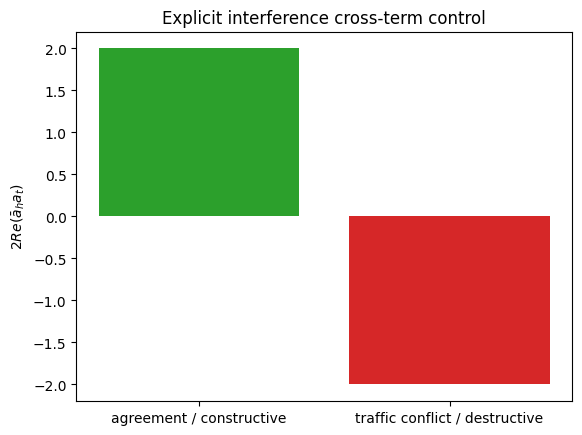

In [ ]:
import copy
import math
import time
from dataclasses import dataclass, field
from typing import Callable, Mapping, Sequence

import numpy as np
import matplotlib.pyplot as plt

@dataclass
class QuantumAmplitudeState:
    """Pheromone memory and last traffic relation for all possible VRP transitions."""
    n: int
    initial: float = 1.0
    pheromone: np.ndarray = field(init=False)

    def __post_init__(self) -> None:
        self.pheromone = np.full((self.n, self.n), self.initial)
        np.fill_diagonal(self.pheromone, 0)

class InterferenceEngine:
    """Build/measure historical and traffic amplitudes; retain every cross term."""

    def __init__(self, problem: DynamicVRP, state: QuantumAmplitudeState, cfg: Mapping[str, object]) -> None:

        self.problem , self.state , self.cfg = problem , state , cfg
        self.log_enabled = bool(cfg.get('log_interference' , True))
        self.log = []

    def scores(
        self,
        i: int,
        candidates: Sequence[int],
        delta: np.ndarray
    ):
        """Return (history, signed_traffic_signal, phase).

        Correct limit behavior: if current weights equal base weights and
        delta == 0, the traffic signal is 0 for every candidate, so the
        traffic amplitude vanishes and interference reduces to classical
        history-based sampling.
        """
        c = np.asarray(candidates, int)
        current = np.maximum(self.problem.weight[i, c], 1e-12)
        base = np.maximum(self.problem.base[i, c], 1e-12)
        change = delta[i, c] / base

        static_eta = (1.0 / base) ** float(self.cfg['beta'])
        history_raw = (self.state.pheromone[i, c] ** float(self.cfg['alpha'])) * static_eta
        history = history_raw / (np.max(history_raw) + 1e-12)

        # Signed traffic signal:
        #  > 0  edge is faster than base (improving)  -> constructive
        #  < 0  edge is congested / worsening         -> destructive
        ratio_signal = np.clip(base / current - 1.0, -0.95, 2.0)
        change_signal = np.clip(-change, -0.95, 2.0)
        signed = 0.7 * ratio_signal + 0.3 * change_signal

        badness = np.clip(-signed, 0.0, 1.0)
        phase = np.minimum(np.pi * badness,
                           float(self.cfg.get('phase_max_fraction', 0.9)) * np.pi)

        return history, signed, phase

    def probabilities(self, i, candidates, delta, traffic_weight,
                      interference_on, classical_control, iteration):
        h, s, phase = self.scores(i, candidates, delta)
        mag = np.clip(np.abs(s), 0.0, 1.0)   # how strongly traffic "speaks"

        wh = float(self.cfg['history_weight'])
        wt = float(traffic_weight)

        if interference_on:
            ah = wh * np.sqrt(np.maximum(h, 0.0)).astype(complex)
            at = wt * np.sqrt(mag) * np.exp(1j * phase)
            cross = 2.0 * np.real(np.conj(ah) * at)
            scores = np.abs(ah + at) ** 2 + 1e-10
        elif classical_control:
            cross = np.zeros_like(h)
            scores = np.maximum(wh * h + wt * np.clip(s, -1.0, 1.0), 1e-10)
        else:
            cross = np.zeros_like(h)
            scores = h + 1e-10

        prob = scores / scores.sum()
        if self.log_enabled:
          for j, x, p, ph in zip(candidates, cross, prob, phase):
            self.log.append({'iteration': iteration, 'i': i, 'j': int(j),
                             'cross_term': float(x), 'probability': float(p),
                             'phase': float(ph)})
        return prob

def interference_demo() -> None:
    """Demonstrate fixed constructive and destructive cases with the exact cross term."""
    ah=np.array([1+0j,1+0j]); at=np.array([1+0j,np.exp(1j*np.pi)])
    cross=2*np.real(np.conj(ah)*at)
    assert cross[0] > 0 and cross[1] < 0
    plt.bar(['agreement / constructive','traffic conflict / destructive'],cross,color=['tab:green','tab:red'])
    plt.ylabel(r'$2 Re(\bar a_h a_t)$'); plt.title('Explicit interference cross-term control'); plt.show()
interference_demo()

## 3. Classical multi-route construction, local exploitation, and dynamic pheromones

Construction assigns customers to vehicle routes one at a time. Capacity/time-window feasibility is applied **before** amplitude measurement. Local search is classical exploitation, not a quantum contribution: it applies feasible 2-opt, relocate, swap, and cross-route relocate moves.

In [ ]:
def solution_key(s: Solution) -> tuple[tuple[int,...],...]: return tuple(tuple(r) for r in s)
def edge_set(s: Solution) -> set[tuple[int,int]]: return {tuple(sorted((i,j))) for r in s for i,j in zip(r[:-1],r[1:])}
def solution_diversity(pop: Sequence[Solution]) -> float:
    """Mean Jaccard edge distance across a population."""
    if len(pop)<2:return 0.0
    vals=[]
    for a in range(len(pop)):
        for b in range(a):
            x,y=edge_set(pop[a]),edge_set(pop[b]); vals.append(1-len(x&y)/max(1,len(x|y)))
    return float(np.mean(vals))
def entropy(tau: np.ndarray) -> float:
    p=tau/(tau.sum(axis=1,keepdims=True)+1e-12); return float(np.mean(-np.sum(p*np.log(p+1e-12),axis=1)/np.log(len(tau))))



class LocalSearch:    # updated local search
    """Best-improvement local search with O(1)/O(n) delta evaluation on the exact
    objective cost matrix C = w_d*base + w_t*weight + w_c*max(weight-base,0).
    Neighbourhoods: 2-opt (intra), relocate (intra + cross-route), swap (cross-route)."""

    def __init__(self, p: DynamicVRP): self.p = p

    # ---------- 2-opt ----------
    def _two_opt(self, w, r):
        L = len(r)
        if L < 5: return r, 0.0
        arr = np.asarray(r); best_gain, best = 1e-9, None
        for a in range(1, L - 2):
            ia, ia1 = arr[a - 1], arr[a]
            seg, nxt = arr[a:L - 1], arr[a + 1:L]
            gain = w[ia, ia1] + w[seg, nxt] - (w[ia, seg] + w[ia1, nxt])
            p = int(np.argmax(gain))
            if gain[p] > best_gain: best_gain, best = float(gain[p]), (a, a + p)
        if best is None: return r, 0.0
        a, b = best
        return r[:a] + r[a:b + 1][::-1] + r[b + 1:], best_gain

    def _two_opt_all(self, w, routes, dem, cap):
        out, tot = [], 0.0
        for r in routes:
            r2, g = self._two_opt(w, r); out.append(r2); tot += g
        return out, tot

    # ---------- relocate, same route (exact) ----------
    def _relocate_intra(self, w, routes, dem, cap):
        best = None
        for x, r in enumerate(routes):
            if len(r) <= 4: continue
            for pos in range(1, len(r) - 1):
                c = r[pos]
                rem = w[r[pos - 1], c] + w[c, r[pos + 1]] - w[r[pos - 1], r[pos + 1]]
                rr = r[:pos] + r[pos + 1:]
                a = np.asarray(rr[:-1]); b = np.asarray(rr[1:])
                ins = w[a, c] + w[c, b] - w[a, b]
                p = int(np.argmin(ins)); g = float(rem) - float(ins[p])
                if g > 1e-9 and (best is None or g > best[0]): best = (g, x, pos, p + 1)
        if best is None: return routes, 0.0
        g, x, pos, p = best
        c = routes[x].pop(pos); routes[x].insert(p, c)
        return routes, g

    # ---------- relocate, cross route (vectorised) ----------
    def _relocate_cross(self, w, routes, dem, cap):
        loads = [float(dem[np.asarray(r[1:-1], int)].sum()) if len(r) > 2 else 0.0 for r in routes]
        best = None
        for x, rx in enumerate(routes):
            if len(rx) <= 3: continue
            inner = np.asarray(rx[1:-1]); px = np.asarray(rx[:-2]); nx = np.asarray(rx[2:])
            rem = w[px, inner] + w[inner, nx] - w[px, nx]
            for y, ry in enumerate(routes):
                if y == x: continue
                ok = (loads[y] + dem[inner]) <= cap + 1e-9
                if not ok.any(): continue
                cand = inner[ok]
                a = np.asarray(ry[:-1]); b = np.asarray(ry[1:])
                ins = w[np.ix_(a, cand)] + w[np.ix_(cand, b)].T - w[a, b][:, None]
                mn, arg = ins.min(axis=0), ins.argmin(axis=0)
                gains = rem[ok] - mn
                p = int(np.argmax(gains))
                if gains[p] > 1e-9 and (best is None or gains[p] > best[0]):
                    best = (float(gains[p]), x, int(np.flatnonzero(ok)[p]) + 1, y, int(arg[p]) + 1)
        if best is None: return routes, 0.0
        g, x, px_, y, py_ = best
        c = routes[x].pop(px_); routes[y].insert(py_, c)
        return [r for r in routes if len(r) > 2], g

    # ---------- swap, cross route (vectorised) ----------
    def _swap_cross(self, w, routes, dem, cap):
        loads = [float(dem[np.asarray(r[1:-1], int)].sum()) if len(r) > 2 else 0.0 for r in routes]
        best = None
        for x in range(len(routes)):
            rx = routes[x]
            if len(rx) <= 3: continue
            cx = np.asarray(rx[1:-1]); px = np.asarray(rx[:-2]); nx = np.asarray(rx[2:])
            for y in range(x + 1, len(routes)):
                ry = routes[y]
                if len(ry) <= 3: continue
                cy = np.asarray(ry[1:-1]); py = np.asarray(ry[:-2]); ny = np.asarray(ry[2:])
                ok = ((loads[x] - dem[cx][:, None] + dem[cy][None, :]) <= cap + 1e-9) & \
                     ((loads[y] - dem[cy][None, :] + dem[cx][:, None]) <= cap + 1e-9)
                if not ok.any(): continue
                A  = w[np.ix_(px, cx)] + w[np.ix_(cx, nx)].T
                A2 = w[np.ix_(py, cy)] + w[np.ix_(cy, ny)].T
                B  = w[np.ix_(px, cy)] + w[np.ix_(cy, nx)].T
                C  = w[np.ix_(py, cx)] + w[np.ix_(cx, ny)].T
                G = (np.diag(A)[:, None] + np.diag(A2)[None, :]) - (B + C.T)
                G = np.where(ok, G, -np.inf)
                i, j = np.unravel_index(int(np.argmax(G)), G.shape)
                if G[i, j] > 1e-9 and (best is None or G[i, j] > best[0]):
                    best = (float(G[i, j]), x, int(i) + 1, y, int(j) + 1)
        if best is None: return routes, 0.0
        g, x, i, y, j = best
        routes[x][i], routes[y][j] = routes[y][j], routes[x][i]
        return routes, g

    def improve(self, s: Solution, budget: int) -> tuple[Solution, int]:
        routes = [list(r) for r in s]
        w = self.p.cost_matrix(); dem = self.p.demand; cap = float(self.p.cfg['capacity'])
        fails = 0
        for _ in range(max(1, int(budget))):
            moved = False
            for fn in (self._two_opt_all, self._relocate_intra, self._relocate_cross, self._swap_cross):
                routes, g = fn(w, routes, dem, cap)
                if g > 1e-9: moved = True
            if not moved:
                fails += 1; break
        return routes, fails


def adaptive_evaporate(state: QuantumAmplitudeState, population: Sequence[Solution], problem: DynamicVRP, rho: float, deposit: float) -> None:
    """Classical pheromone learning; its dynamic evaporation is distinct from amplitude interference."""
    state.pheromone *= (1-rho)
    for s in population:
        q=deposit/max(problem.objective_parts(s)['objective'],1e-9)
        for r in s:
            for i,j in zip(r[:-1],r[1:]): state.pheromone[i,j]+=q; state.pheromone[j,i]+=q
    state.pheromone=np.maximum(state.pheromone,1e-9)

## 4. Tunneling-inspired nonlocal transitions and adaptive barrier acceptance

The operator tries large segment reversal, segment relocation, cross-route block relocation, route exchange, or a traffic-shock repair. It preserves feasibility. Unlike V1, a feasible candidate beyond a modest fitness barrier may be accepted with `exp(-ΔF/T_tunnel)`; temperature falls through the run but rises with stagnation/volatility. This is an analogy for exploration, not literal physical tunneling.

In [ ]:
class TunnelingOperator:
    """Feasibility-preserving nonlocal VRP basin-transition operator."""

    def __init__(self, p: DynamicVRP, rng: np.random.Generator):
        self.p = p
        self.rng = rng

    def _obj(self, s: Solution) -> float:
        """Fast objective evaluation using cached cost matrix."""
        C = self.p.cost_matrix()
        return sum(float(C[np.asarray(r[:-1]), np.asarray(r[1:])].sum()) for r in s) \
               + float(self.p.cfg['objective_vehicles']) * len(s)

    def propose(self, s: Solution, affected: list[int] | None = None) -> Solution:
        original = copy.deepcopy(s)
        base_obj = self.p.objective_parts(original)['objective']
        feasible_candidates: list[tuple[float, Solution]] = []

        for _ in range(int(self.p.cfg.get('tunnel_proposals', 8))):
            z = copy.deepcopy(original)

            nonempty = [k for k, r in enumerate(z) if len(r) > 3]
            if affected:
                target = list(set(nonempty) & set(affected)) or nonempty
            else:
                target = nonempty

            if not target:
                return original

            op = int(self.rng.integers(4))

            if op == 0:
                # Large segment reversal.
                k = int(self.rng.choice(target))
                r = z[k]
                if len(r) > 4:
                    a = int(self.rng.integers(1, max(2, len(r) - 2)))
                    b = int(self.rng.integers(a + 1, len(r) - 1))
                    z[k] = r[:a] + r[a:b + 1][::-1] + r[b + 1:]

            elif op == 1:
                # Large segment relocation inside the same route.
                k = int(self.rng.choice(target))
                r = z[k]
                if len(r) > 5:
                    a = int(self.rng.integers(1, len(r) - 3))
                    b = min(len(r) - 1, a + int(self.rng.integers(1, 3)))
                    block = r[a:b]
                    del z[k][a:b]
                    pos = int(self.rng.integers(1, max(2, len(z[k]) - 1)))
                    z[k][pos:pos] = block

            elif op == 2 and len(z) > 1:
                # Cross-route node relocation with capacity check.
                x = int(self.rng.choice(target))
                others = [k for k in range(len(z)) if k != x]
                if others and len(z[x]) > 3:
                    y = int(self.rng.choice(others))
                    pos = int(self.rng.integers(1, len(z[x]) - 1))
                    node = z[x].pop(pos)

                    load_y = sum(self.p.demand[c] for c in z[y][1:-1]) + self.p.demand[node]
                    if load_y <= float(self.p.cfg['capacity']) + 1e-9:
                        z[y].insert(len(z[y]) - 1, node)
                    else:
                        z[x].insert(pos, node)

            else:
                # Swap customers between two routes.
                if len(z) > 1:
                    x, y = self.rng.choice(len(z), 2, replace=False)
                    x, y = int(x), int(y)
                    if len(z[x]) > 3 and len(z[y]) > 3:
                        px = int(self.rng.integers(1, len(z[x]) - 1))
                        py = int(self.rng.integers(1, len(z[y]) - 1))
                        z[x][px], z[y][py] = z[y][py], z[x][px]

            if self.p.feasible(z) and solution_key(z) != solution_key(original):
                obj = self.p.objective_parts(z)['objective']
                feasible_candidates.append((obj, z))

                # If we already found an improving nonlocal move, return it immediately.
                if obj < base_obj:
                    return z

        if feasible_candidates:
            feasible_candidates.sort(key=lambda item: item[0])
            return feasible_candidates[0][1]

        return original

    def tunnel_accept(self, current: float, new: float, iteration: int, total: int, stagnation: int,volatility: float,cfg: Mapping[str, object],rng: np.random.Generator) -> bool:
        """Accept improvements; otherwise cross only bounded relative barriers."""
        if new <= current:
            return True

        delta = (new - current) / max(abs(current), 1e-12)
        barrier_max = float(cfg.get('tunnel_barrier_max', 0.18))

        # Do not allow crossing huge barriers.
        if delta > barrier_max:
            return False

        temp = (float(cfg['tunnel_temperature'])* (0.30 + 0.70 * (1.0 - iteration / max(total, 1)))* (1.0 + min(stagnation / float(cfg['S_max']), 2.0) + 4.0 * volatility))

        exponent = min(delta / max(temp, 1e-12), 40.0)
        return bool(rng.random() < math.exp(-exponent))

@dataclass
class AdaptiveController:
    """Maps observed search state into bounded exploration/exploitation controls."""
    cfg: Mapping[str, object]

    def controls(
        self,
        stagnation: int,
        diversity: float,
        volatility: float,
        ls_fail: int,
        adaptive: bool
    ) -> dict[str, float]:
        stag = stagnation / max(float(self.cfg['S_max']), 1.0)

        if adaptive:
            pressure = np.clip(
                0.45 * stag +
                0.25 * (1.0 - diversity) +
                3.0 * volatility +
                0.12 * ls_fail,
                0.0,
                1.0
            )
        else:
            # Even without full adaptation, tunneling should respond to stagnation.
            pressure = np.clip(stag, 0.0, 1.0)

        traffic_weight = float(self.cfg['traffic_weight'])
        candidate_k = int(self.cfg['candidate_k'])
        rho = float(self.cfg['rho'])
        ls_budget = int(self.cfg['local_search_moves'])

        if adaptive:
            traffic_weight = float(np.clip(
                traffic_weight * (1.0 + 1.4 * pressure),
                0.25,
                1.75
            ))

            candidate_k = int(np.clip(
                int(self.cfg['candidate_k']) + round(4.0 * pressure),
                int(self.cfg['candidate_k_min']),
                int(self.cfg['candidate_k_max'])
            ))

            rho = float(np.clip(
                rho + 0.22 * pressure,
                float(self.cfg['rho_min']),
                float(self.cfg['rho_max'])
            ))

            ls_budget = int(np.clip(
                int(self.cfg['local_search_moves']) + round(4.0 * (1.0 - pressure)),
                1,
                8
            ))

        tunnel_p = (1.0 if bool(self.cfg.get('force_tunneling_on', False))
                    else float(np.clip(0.12 + 0.60 * pressure, 0.12, 0.80)))

        return {
            'traffic_weight': traffic_weight,
            'candidate_k': candidate_k,
            'rho': rho,
            'ls_budget': ls_budget,
            'tunnel_p': tunnel_p
        }

## 5. Unified dynamic VRP ACO runner and partial reconstruction

The common runner lets every ablation flip only flags. On a shock, it identifies routes containing changed edges, freezes the other routes, removes affected customers, and reconstructs only the affected routes with the same traffic-aware decision engine. Metrics record the scope and runtime of this localized response.

In [ ]:
class DynamicQACO:
    """Unified, reproducible ACO/QACO dynamic-VRP engine."""
    def __init__(self,cfg:Mapping[str,object],flags:Mapping[str,bool]):
        self.cfg={**cfg}; self.flags={**FLAGS,**flags}; self.p=DynamicVRP(self.cfg); self.rng=np.random.default_rng(int(self.cfg['seed']))
        self.state=QuantumAmplitudeState(len(self.p.demand)); self.interference=InterferenceEngine(self.p,self.state,self.cfg); self.local=LocalSearch(self.p); self.tunneler=TunnelingOperator(self.p,self.rng); self.controller=AdaptiveController(self.cfg)



    def _build(self, delta, controls, customers=None, fixed=None):
        """Vectorised capacitated multi-route construction (candidate filter -> amplitudes -> sample)."""
        cap = float(self.cfg['capacity']); max_routes = int(self.cfg['n_vehicles'])
        k = int(controls['candidate_k'])
        W = self.p.cost_matrix(); dem = self.p.demand; tw = self.p.tw_close
        n = len(dem)

        remaining = np.zeros(n, dtype=bool)
        if customers is None: remaining[1:] = True
        else:                 remaining[list(customers)] = True

        routes = [list(r) for r in (fixed or [])]
        while remaining.any() and len(routes) < max_routes:
            route = [0]; load = 0.0; clock = 0.0
            while True:
                i = route[-1]
                cand = np.flatnonzero(remaining)
                fit = cand[(load + dem[cand]) <= cap + 1e-9]
                if self.p._limit_on and fit.size:
                    fit = fit[(clock + W[i, fit]) <= tw[fit]]
                if fit.size == 0: break
                d = W[i, fit]; m = min(k, fit.size)
                short = fit[np.argpartition(d, m - 1)[:m]] if m < fit.size else fit
                prob = self.interference.probabilities(
                    i, short, delta, controls['traffic_weight'],
                    self.flags['interference_on'], self.flags['classical_fusion_control'],
                    self.iteration)
                j = int(short[self.rng.choice(len(short), p=prob)])
                route.append(j); remaining[j] = False
                load += dem[j]; clock += W[i, j]
            route.append(0)
            if len(route) > 2: routes.append(route)
            else: break

        if remaining.any():
            routes = self._repair_insert(routes, np.flatnonzero(remaining))
        return routes

    def _repair_insert(self, routes, missing):
        """Randomised cheapest-insertion repair; opens new routes if needed."""
        W = self.p.cost_matrix(); dem = self.p.demand
        cap = float(self.cfg['capacity']); max_routes = int(self.cfg['n_vehicles'])
        for c in self.rng.permutation(np.asarray(missing, dtype=int)):
            c = int(c); best = None
            for ri, r in enumerate(routes):
                inner = np.asarray(r[1:-1], dtype=int)
                if inner.size and float(dem[inner].sum()) + dem[c] > cap + 1e-9: continue
                a = np.asarray(r[:-1]); b = np.asarray(r[1:])
                cost = W[a, c] + W[c, b] - W[a, b]
                p = int(np.argmin(cost))
                if best is None or float(cost[p]) < best[0]: best = (float(cost[p]), ri, p + 1)
            if best is not None:                 routes[best[1]].insert(best[2], c)
            elif len(routes) < max_routes:       routes.append([0, c, 0])
            else:
                loads = [float(dem[np.asarray(r[1:-1], int)].sum()) for r in routes]
                routes[int(np.argmin(loads))].insert(1, c)   # last resort -> violation+penalty
        return routes

    def partial_reconstruct(self,s:Solution,delta:np.ndarray,controls:Mapping[str,float])->tuple[Solution,int,int,int]:
        """Freeze unaffected routes; reconstruct customer portions from shock-affected routes only."""
        affected=self.p.affected_route_indices(s)
        if not affected:return s,0,0,0
        frozen=[r for k,r in enumerate(s) if k not in affected]; pool=[c for k in affected for c in s[k][1:-1]]
        started=time.perf_counter(); rebuilt=self._build(delta,controls,pool,frozen); elapsed=int((time.perf_counter()-started)*1000)
        return rebuilt,len(affected),elapsed,len(pool)

    def run(self) -> tuple[list[dict[str, float]], list[dict[str, float]] , solution]:
        records = []
        unique = set()

        best = None
        bestv = float('inf')
        current = None

        stagnation = 0
        ls_fail = 0

        tunnel_proposals = 0
        tunnel_feasible = 0
        tunnel_accepted = 0
        tunnel_improved = 0

        last_diversity = 0.0
        last_reconstruct = -999

        start = time.perf_counter()

        for self.iteration in range(int(self.cfg['iterations'])):
            shock_reconstruct_required = False
            # Preferentially shock edges used by current incumbent so dynamic effect is visible.
            prefer_edges = edge_set(current) if current is not None else None
            vol, delta = self.p.advance(self.iteration, bool(self.flags['dynamic_on']), prefer_edges)

                        # Validation helper: if a shock iteration occurs but the incumbent
            # is not affected, force some shocked edges to belong to the incumbent.
            if (
                bool(self.flags['dynamic_on'])
                and self.iteration in self.p.cfg['shock_iterations']
                and current is not None
                and not self.cfg.get('shock_plan')  # BRIDGE: preserve an explicit shared replay plan.
            ):
                if len(self.p.affected_route_indices(current)) == 0:
                    current_edges = list(edge_set(current))

                    if len(current_edges) >= 2:
                        rng_shock = np.random.default_rng(
                            int(self.cfg['seed']) + self.iteration + 777
                        )

                        m = max(
                            2,
                            int(len(current_edges)
                                * float(self.cfg.get('shock_edge_fraction', 0.25))
                                * max(1.0, float(self.cfg['shock_strength']) / 4.0))
                        )

                        chosen_idx = rng_shock.choice(
                            len(current_edges),
                            size=min(m, len(current_edges)),
                            replace=False
                        )

                        chosen_edges = [
                            tuple(sorted(current_edges[int(k)]))
                            for k in chosen_idx
                        ]

                        duration = int(self.cfg.get('shock_duration', 30))

                        for e in chosen_edges:
                            self.p.active_shocks[e] = self.iteration + duration

                        self.p.changed_edges = set(self.p.active_shocks.keys())

                        # Apply shock to weights immediately.
                        shock = np.zeros_like(self.p.base)
                        for ii, jj in self.p.changed_edges:
                            shock[ii, jj] = shock[jj, ii] = float(self.cfg['shock_strength'])

                        factor_t = self.p._weight_t / torch.clamp(self.p._base_t, min=1e-12)

                        self.p.previous = self.p.weight.copy()
                        shock_t = torch.as_tensor(shock, dtype=self.p._base_t.dtype, device=self.p.device)
                        self.p._weight_t = self.p._base_t * torch.clamp(factor_t + shock_t, min=0.05)
                        self.p.weight = self.p._weight_t.cpu().numpy()
                        self.p.weight.fill_diagonal(0.0)

                        delta = self.p.weight - self.p.previous
                        vol = float(torch.linalg.vector_norm(self.p._weight_t - self.p._previous_t)
                                    / (torch.linalg.vector_norm(self.p._previous_t) + 1e-12))
                        shock_reconstruct_required = True

            ctl = self.controller.controls(stagnation,last_diversity,vol,ls_fail,bool(self.flags['adaptive_on']))

            pop = [self._build(delta, ctl)for _ in range(int(self.cfg['num_ants']))]

            raw_vals = [self.p.objective_parts(s)['objective'] for s in pop]
            pre_local_best = float(min(raw_vals)) if raw_vals else float('inf')

            if self.flags['local_search_on']:
                # Improve only the best quarter of the population.
                # This prevents deterministic local search from erasing all construction diversity.
                idxs = np.argsort(raw_vals)[:max(1, len(pop) // 4)]
                failures = []

                for ix in idxs:
                    pop[int(ix)], f = self.local.improve(pop[int(ix)], int(ctl['ls_budget']))
                    failures.append(f)

                ls_fail = int(np.mean(failures)) if failures else 0

            vals = [self.p.objective_parts(s)['objective'] for s in pop]
            candidate = pop[int(np.argmin(vals))]
            cv = min(vals)

            if (current is None or cv < self.p.objective_parts(current)['objective']) \
                    and not shock_reconstruct_required:
                current = copy.deepcopy(candidate)

            affected_idx = self.p.affected_route_indices(current) if current is not None else []
            affected = len(affected_idx)
            rebuild_ms = 0
            reconstructed_customers = 0

            if bool(self.flags.get('partial_reconstruct_on', False)) and affected_idx:
                cooldown = int(self.cfg.get('reconstruct_cooldown', 3))
                should_rebuild = (vol > float(self.cfg['volatility_reconstruct_threshold'])or (self.iteration - last_reconstruct) >= cooldown)

                if should_rebuild:
                    current, affected_count, rebuild_ms, reconstructed_customers = self.partial_reconstruct(current, delta, ctl)
                    affected = affected_count
                    last_reconstruct = self.iteration

                    if self.flags['local_search_on']:
                        current, _ = self.local.improve(current, max(1, int(ctl['ls_budget'])))

            force_tunneling = bool(self.cfg.get('force_tunneling_on', False))
            want_tunnel = (
                self.flags['tunneling_on']
                and current is not None
                and (
                    force_tunneling
                    and self.iteration >= max(1, int(self.cfg['S_max']) // 2)
                    or stagnation >= int(self.cfg['S_max'])
                    or (
                        affected > 0
                        and stagnation >= max(1, int(self.cfg['S_max']) // 3)
                    )
                )
            )

            if want_tunnel and self.rng.random() < float(ctl['tunnel_p']):
                tunnel_proposals += 1

                proposal = self.tunneler.propose(current,self.p.affected_route_indices(current))

                old = self.p.objective_parts(current)['objective']
                new = self.p.objective_parts(proposal)['objective']

                if solution_key(proposal) != solution_key(current):
                    tunnel_feasible += 1

                    if self.tunneler.tunnel_accept(old,new,self.iteration,int(self.cfg['iterations']),stagnation,vol,self.cfg,self.rng):
                        current = proposal
                        tunnel_accepted += 1

                        if new < old:
                            tunnel_improved += 1

            value = self.p.objective_parts(current)['objective']

            if value < bestv - 1e-9:
                best = copy.deepcopy(current)
                bestv = value
                stagnation = 0
            else:
                stagnation += 1

            adaptive_evaporate(self.state,pop,self.p,float(ctl['rho']),float(self.cfg['deposit']))

            unique.update(solution_key(s) for s in pop)

            pop_diversity = solution_diversity(pop)
            last_diversity = pop_diversity

            parts = self.p.objective_parts(current)

            records.append({
                **parts,
                'iteration': self.iteration,
                'runtime_s': time.perf_counter() - start,
                'pre_local_best': pre_local_best,
                'volatility': vol,
                'diversity': pop_diversity,
                'edge_diversity': len(set().union(*[edge_set(x) for x in pop])) if pop else 0,
                'entropy': entropy(self.state.pheromone),
                'unique_solutions': len(unique),
                'stagnation': stagnation,
                'traffic_weight': float(ctl['traffic_weight']),
                'tunnel_p': float(ctl['tunnel_p']),
                'tunneling_events': tunnel_proposals,
                'tunnel_feasible': tunnel_feasible,
                'successful_tunnels': tunnel_accepted,
                'improving_tunnels': tunnel_improved,
                'affected_routes': affected,
                'reconstructed_customers': reconstructed_customers,
                'reconstruction_ms': rebuild_ms,
            })

        self.final_solution = copy.deepcopy(current)  # BRIDGE: export the final traffic-state route.
        return records, self.interference.log , best

## 5. Bridge B — ORS costs and one-time GAT pheromone initialization

The original shock method operates on a baseline matrix and produces weighted
travel costs. The adapter supplies **ORS durations in seconds** as that baseline;
separate **ORS distances in metres** supply the distance objective. Thus:

`objective = 0.25 × distance_m + 1.0 × current_travel_s + 1.75 × delay_s`

plus the original vehicle and feasibility terms. This is the source's weighted
objective, not a quantity with a single physical unit. `delay_s=max(current_s−base_s,0)`.
The original drift, shock magnitude, shock iterations `(4,8,11)`, duration,
phase construction, interference, tunneling, and learning equations remain.
Its pairwise shock hits both travel directions; ORS costs themselves remain
asymmetric. The source also deposits pheromone in both directions; that rule
is retained.

The original 2-opt shortcut assumes symmetric costs. Two extra lines account
for reversed internal arc costs on ORS roads; the operator suite is unchanged.
A tensor synchronization seam lets the original OR-Tools replay helper replace
`weight` safely. An explicit shared shock plan, when configured, is passed to
the unchanged source `advance` method; otherwise its incumbent-targeted shocks
run exactly as supplied.

In [ ]:
SourceDynamicVRP = DynamicVRP
SourceLocalSearch = LocalSearch

class BengaluruORSVRP(SourceDynamicVRP):
    def __post_init__(self):
        super().__post_init__()
        ids = np.asarray(self.cfg.get('ors_node_ids', np.arange(n_ors)), dtype=int)
        if len(ids) != len(self.coords) or not np.array_equal(self.coords, _c[ids]):
            raise ValueError('Instance coordinates do not match their ORS node IDs.')
        self.ors_node_ids = ids
        self.road_distances = np.asarray(base_distances[np.ix_(ids, ids)], float).copy()
        self._distance_t = torch.as_tensor(self.road_distances, dtype=self._base_t.dtype, device=self.device)
        self._base_t = torch.as_tensor(base_durations[np.ix_(ids, ids)].copy(),
                                       dtype=self._base_t.dtype, device=self.device)
        self.base = self._base_t.cpu().numpy().copy()
        self._weight_t = self._base_t.clone()
        self._previous_t = self._weight_t.clone()
        self.weight = self._weight_t.cpu().numpy().copy()
        self.previous = self.weight.copy()
        self.invalidate()

    def invalidate(self):
        # The inherited OR-Tools replay assigns NumPy weight directly.
        self._weight_t = torch.as_tensor(self.weight, dtype=self._base_t.dtype, device=self.device)
        super().invalidate()

    def cost_matrix(self):
        if self._cost is None:
            delay = torch.clamp(self._weight_t - self._base_t, min=0)
            self._cost = (float(self.cfg['objective_distance']) * self._distance_t
                          + float(self.cfg['objective_time']) * self._weight_t
                          + float(self.cfg['objective_congestion']) * delay).cpu().numpy()
        return self._cost

    def objective_parts(self, solution):
        parts = super().objective_parts(solution)
        parts['distance'] = sum(float(self.road_distances[
            np.asarray(r[:-1]), np.asarray(r[1:])].sum()) for r in solution)
        return parts

    def advance(self, iteration, dynamic, prefer_edges=None):
        plan = self.cfg.get('shock_plan')
        if plan:
            prefer_edges = plan.get(iteration)
        return super().advance(iteration, dynamic, prefer_edges)

class BengaluruDirectedLocalSearch(SourceLocalSearch):
    def _two_opt(self, w, r):
        L = len(r)
        if L < 5: return r, 0.0
        arr = np.asarray(r); best_gain, best = 1e-9, None
        for a in range(1, L - 2):
            ia, ia1 = arr[a - 1], arr[a]
            seg, nxt = arr[a:L - 1], arr[a + 1:L]
            gain = w[ia, ia1] + w[seg, nxt] - (w[ia, seg] + w[ia1, nxt])
            internal = w[arr[a:L-2], arr[a+1:L-1]] - w[arr[a+1:L-1], arr[a:L-2]]
            gain += np.r_[0.0, np.cumsum(internal)]  # BRIDGE: exact directed reversal cost.
            p = int(np.argmax(gain))
            if gain[p] > best_gain: best_gain, best = float(gain[p]), (a, a + p)
        if best is None: return r, 0.0
        a, b = best
        return r[:a] + r[a:b + 1][::-1] + r[b + 1:], best_gain

# The original runner resolves these dependencies when it is instantiated.
DynamicVRP = BengaluruORSVRP
LocalSearch = BengaluruDirectedLocalSearch

class GATDynamicQACO(DynamicQACO):
    def __init__(self, cfg, flags):
        super().__init__(cfg, flags)
        ids = self.p.ors_node_ids
        prior = GAT_ORS_PRIOR[np.ix_(ids, ids)].copy()
        if prior.shape != self.state.pheromone.shape or not np.isfinite(prior).all():
            raise ValueError('GAT prior/QACO node mismatch or nonfinite prior.')
        if (prior < 0).any() or (prior > 1).any():
            raise ValueError('Expected sigmoid GAT probabilities in [0, 1].')
        prior = np.maximum(prior, 0.001)
        np.fill_diagonal(prior, 0.0)
        prior /= prior.sum(axis=1, keepdims=True) / (len(ids) - 1)
        self.state.pheromone = prior
        self.initial_gat_pheromone = prior.copy()
        # No override of run/build/interference/tunneling: one-time injection only.


## 6. Execute the GAT + QACO hybrid with the original dynamic shocks

This is the integrated run. Every dynamic mechanism is enabled using the source
flags and default budget (12 iterations × 6 ants). `source_historical_best`
retains the original runner's across-time minimum return, which can belong to
an earlier traffic state. Reports and exports below use **final_solution** at
the final traffic state instead. A shorter run is a mechanism demonstration,
not evidence of superior routing or complete recovery after the last shock.

In [ ]:
HYBRID_FLAGS = {
    'interference_on': True, 'tunneling_on': True,
    'local_search_on': True, 'adaptive_on': True,
    'dynamic_on': True, 'partial_reconstruct_on': True,
}
HYBRID_CFG = {**CFG, 'log_interference': True}
hybrid = GATDynamicQACO(HYBRID_CFG, HYBRID_FLAGS)
hybrid_records, hybrid_interference, source_historical_best = hybrid.run()
hybrid_final_routes = copy.deepcopy(hybrid.final_solution)
assert hybrid.p.feasible(hybrid_final_routes)
assert all(r['violations'] == 0 for r in hybrid_records)
assert np.isclose(hybrid.p.objective_parts(hybrid_final_routes)['objective'],
                  hybrid_records[-1]['objective'])
hybrid_metrics = pd.DataFrame(hybrid_records)
display(hybrid_metrics[['iteration', 'objective', 'distance', 'travel_time', 'congestion',
                        'vehicles', 'violations', 'affected_routes', 'reconstructed_customers',
                        'tunneling_events', 'successful_tunnels']])
print('Final-state routes:', hybrid_final_routes)
print('Distance: metres; travel_time and congestion: seconds.')
hybrid_metrics.to_csv(ARTIFACT_DIR / 'gat_qaco_dynamic_metrics.csv', index=False)
pd.DataFrame(hybrid_interference).to_csv(ARTIFACT_DIR / 'gat_qaco_interference.csv', index=False)
(ARTIFACT_DIR / 'gat_qaco_final_routes.json').write_text(json.dumps({
    'iteration': int(hybrid_records[-1]['iteration']),
    'routes': hybrid_final_routes,
    'metrics': hybrid.p.objective_parts(hybrid_final_routes),
    'depot_node_id': 0,
    'node_mapping': 'bengaluru_node_mapping.csv',
    'capacity': float(HYBRID_CFG['capacity']),
    'demand_origin': 'original QACO synthetic 10/30 pattern',
}, indent=2))


,iteration,objective,distance,travel_time,congestion,vehicles,violations,affected_routes,reconstructed_customers,tunneling_events,successful_tunnels
0,0,9005.407227,25740.23,2570.350098,0.000000,1.0,0.0,0,0,0,0
1,1,9004.251953,25740.23,2569.194336,0.000000,1.0,0.0,0,0,0,0
2,2,9004.066406,25740.23,2569.008057,0.000000,1.0,0.0,0,0,1,1
3,3,9120.045898,25740.23,2646.499268,21.993896,1.0,0.0,0,0,2,2
4,4,9080.715820,25740.23,2634.599609,6.318909,1.0,0.0,1,19,3,2
5,5,9069.929688,25740.23,2629.160645,3.263428,1.0,0.0,1,0,4,3
6,6,9047.937500,25740.23,2612.543701,0.192017,1.0,0.0,1,0,5,4
7,7,9044.352539,25740.23,2609.295166,0.000000,1.0,0.0,1,19,6,4
8,8,12346.906250,29845.49,3775.766602,634.152588,1.0,0.0,1,19,7,5
9,9,10927.902344,25740.23,3357.904053,648.537720,1.0,0.0,1,0,8,6


Final-state routes: [[0, 12, 13, 1, 16, 11, 19, 10, 5, 15, 9, 2, 14, 4, 3, 17, 8, 7, 18, 6, 0]]
Distance: metres; travel_time and congestion: seconds.


599

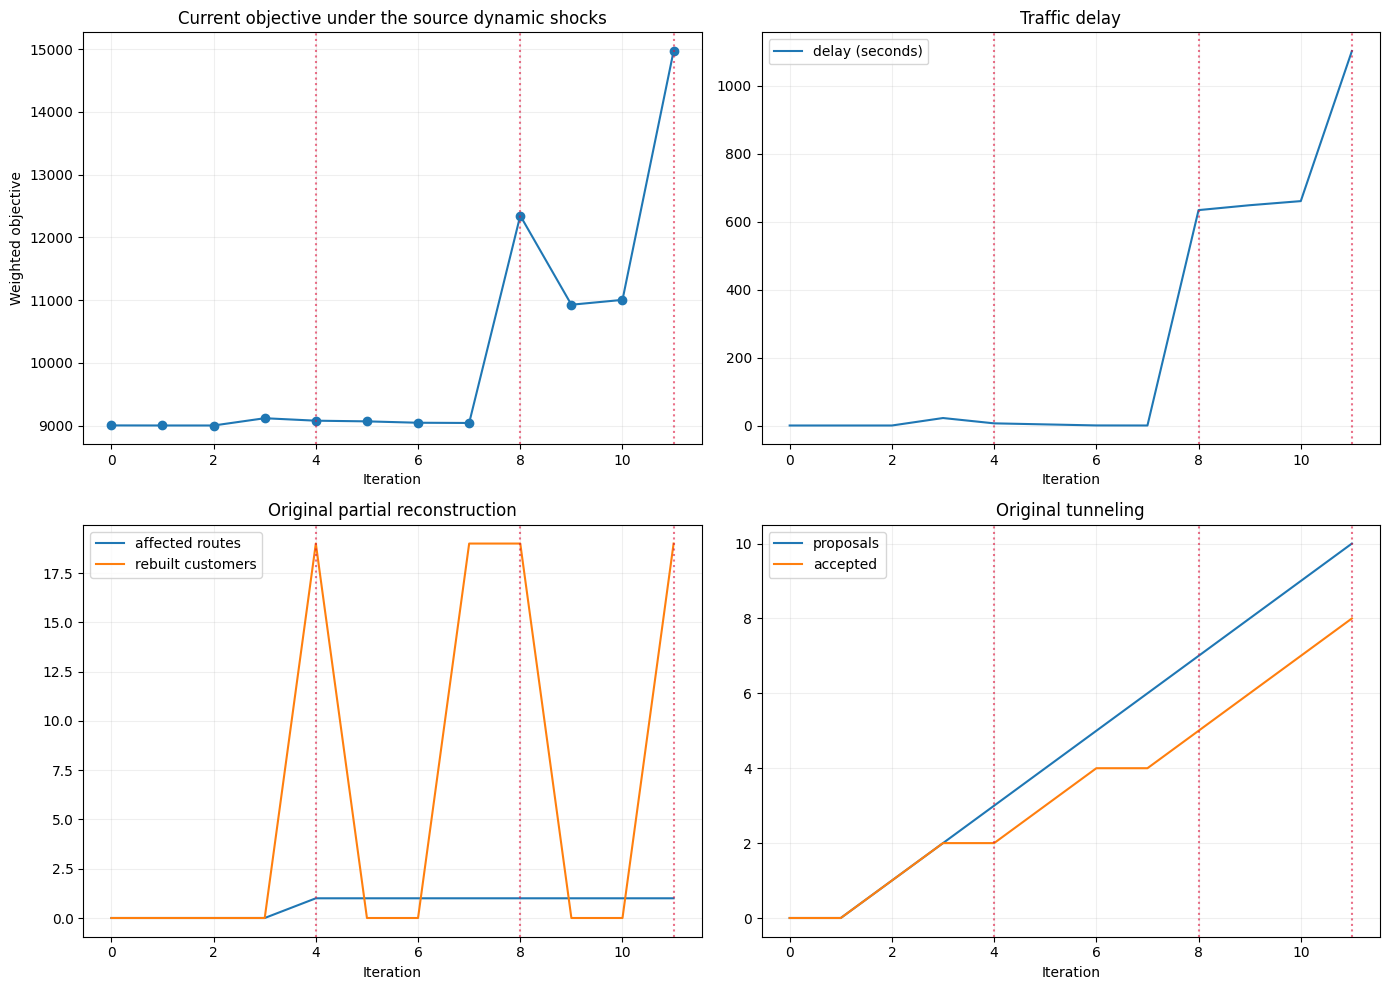

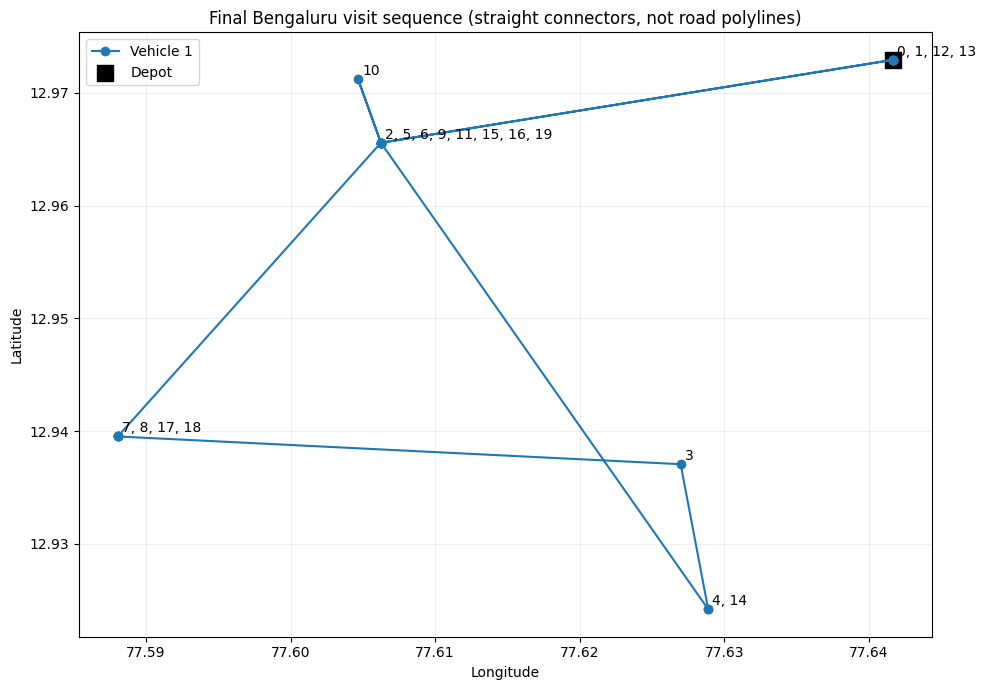

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(hybrid_metrics['iteration'], hybrid_metrics['objective'], marker='o')
axes[0, 0].set_title('Current objective under the source dynamic shocks')
axes[0, 0].set_ylabel('Weighted objective')
axes[0, 1].plot(hybrid_metrics['iteration'], hybrid_metrics['congestion'], label='delay (seconds)')
axes[0, 1].set_title('Traffic delay'); axes[0, 1].legend()
axes[1, 0].plot(hybrid_metrics['iteration'], hybrid_metrics['affected_routes'], label='affected routes')
axes[1, 0].plot(hybrid_metrics['iteration'], hybrid_metrics['reconstructed_customers'], label='rebuilt customers')
axes[1, 0].set_title('Original partial reconstruction'); axes[1, 0].legend()
axes[1, 1].plot(hybrid_metrics['iteration'], hybrid_metrics['tunneling_events'], label='proposals')
axes[1, 1].plot(hybrid_metrics['iteration'], hybrid_metrics['successful_tunnels'], label='accepted')
axes[1, 1].set_title('Original tunneling'); axes[1, 1].legend()
for ax in axes.flat:
    for it in HYBRID_CFG['shock_iterations']: ax.axvline(it, color='crimson', ls=':', alpha=0.6)
    ax.set_xlabel('Iteration'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.get_cmap('tab20')(np.linspace(0, 1, len(hybrid_final_routes)))
for k, route in enumerate(hybrid_final_routes):
    coords = hybrid.p.coords[np.asarray(route)]
    ax.plot(coords[:, 0], coords[:, 1], '-o', color=colors[k], label=f'Vehicle {k + 1}')
for (lon, lat), nodes_at_point in node_table.groupby(['Longitude', 'Latitude']):
    label = ', '.join(str(i) for i in nodes_at_point['node_id'])
    ax.annotate(label, (lon, lat), xytext=(3, 3), textcoords='offset points')
ax.scatter(*hybrid.p.coords[0], marker='s', s=130, color='black', label='Depot')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Final Bengaluru visit sequence (straight connectors, not road polylines)')
ax.legend(); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()


## 7. Original smoke checks and retained benchmark sections

The original smoke check remains active. The longer OR-Tools and ablation blocks
run only when `RUN_LEGACY_BENCHMARKS=True` above. They retain the original
**non-GAT baseline runner** so the classical labels retain their meaning.
The integrated GAT run is the separate section above.

Original benchmark comments claiming held-out accuracy, complete recovery,
multi-seed rigor, or an exact optimum should not be inferred from a 12-iteration,
one-seed execution. The original dynamic empirical reference pools different
traffic states; treat it only as that source's descriptive diagnostic. Its
OR-Tools warm-start input may fall back to a cold start.

In [ ]:
# --- Shock targeting verification (run once) ---
'''p_test = DynamicVRP(CFG)
dummy = [[0, 1, 2, 3, 0], [0, 4, 5, 6, 0]]
s0 = int(CFG['shock_iterations'][0])

p_test.advance(s0, True, prefer_edges=edge_set(dummy))

affected = p_test.affected_route_indices(dummy)
print('shock iteration:', s0)
print('n changed edges:', len(p_test.changed_edges))
print('affected routes:', affected)

assert len(affected) >= 1, 'shock did not hit the provided edges'
print('shock targeting OK')'''

"p_test = DynamicVRP(CFG)\ndummy = [[0, 1, 2, 3, 0], [0, 4, 5, 6, 0]]\ns0 = int(CFG['shock_iterations'][0])\n\np_test.advance(s0, True, prefer_edges=edge_set(dummy))\n\naffected = p_test.affected_route_indices(dummy)\nprint('shock iteration:', s0)\nprint('n changed edges:', len(p_test.changed_edges))\nprint('affected routes:', affected)\n\nassert len(affected) >= 1, 'shock did not hit the provided edges'\nprint('shock targeting OK')"

#updated version of the above cell

In [ ]:
p_test = DynamicVRP(CFG)
dummy = [[0] + list(range(1, len(p_test.demand))) + [0]]  # BRIDGE: actual Bengaluru IDs.
s0 = int(CFG['shock_iterations'][0])
p_test.advance(s0, True, prefer_edges=sorted(edge_set(dummy)))
affected = p_test.affected_route_indices(dummy)
print('shock iteration:', s0, '| changed edges:', len(p_test.changed_edges), '| affected:', affected)
assert len(affected) >= 1 and len(p_test.changed_edges) <= int(CFG['shock_max_edges'])
print('shock targeting OK')

shock iteration: 4 | changed edges: 20 | affected: [0]
shock targeting OK


In [ ]:
# ---- 1. smoke test on the FULL instance -------------------------------
SMOKE = {**CFG, 'iterations': 5, 'num_ants': 4, 'candidate_k': 8}
eng = DynamicQACO(SMOKE, {'interference_on': True, 'tunneling_on': True,
                          'local_search_on': True, 'adaptive_on': True,
                          'dynamic_on': True, 'partial_reconstruct_on': True})
import time as _t; t0 = _t.perf_counter()
recs, _ , _ = eng.run(); dt = _t.perf_counter() - t0
print(f"5 iterations / 4 ants took {dt:.1f}s  -> full run estimate "
      f"{dt/5*CFG['iterations']*CFG['num_ants']/4/60:.1f} min")
print({k: round(v, 2) for k, v in recs[-1].items() if k in
       ('objective','distance','vehicles','violations','congestion','volatility')})
assert all(r['violations'] == 0 for r in recs), 'INFEASIBLE -> raise n_vehicles'
print('deposit calibration suggestion:', round(0.04 * recs[-1]['objective'], 1))

# ---- 2. subset harness (use for the 17-variant ablation grid) ---------
def make_subset(keep=100, seed=3, slack=1.6):
    keep = min(int(keep), n_ors - 1)
    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(np.arange(1, len(INSTANCE['coords'])), size=keep, replace=False))
    idx = np.concatenate([[0], idx])
    c, d = INSTANCE['coords'][idx], INSTANCE['demand'][idx]
    lb = int(np.ceil(d[1:].sum() / INSTANCE['capacity']))
    cfg = {**CFG, 'ors_node_ids': idx, 'n_customers': keep, 'n_vehicles': max(lb + 1, int(np.ceil(lb * slack))),
           'candidate_k': 10, 'candidate_k_min': 6, 'candidate_k_max': 18}
    return c, d, cfg

def use_full_instance():
    set_instance(_c, _d, _cap, _dl, 'bengaluru_ors_first20')

5 iterations / 4 ants took 0.1s  -> full run estimate 0.0 min
{'distance': 32416.09, 'congestion': 133.67, 'vehicles': 1.0, 'violations': 0.0, 'objective': 11957.61, 'volatility': 0.62}
deposit calibration suggestion: 478.3


In [ ]:
if RUN_LEGACY_BENCHMARKS:
    get_ipython().run_line_magic("pip", 'install -q "ortools==9.14.6206"')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 29.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.


In [ ]:
if RUN_LEGACY_BENCHMARKS:
    import google.protobuf
    import ortools

    print("Protobuf:", google.protobuf.__version__)
    print("OR-Tools:", ortools.__version__)

    from ortools.constraint_solver import pywrapcp, routing_enums_pb2
    import numpy as np
    import time

    print("OR-Tools imported successfully")

Protobuf: 6.31.1
OR-Tools: 9.14.6206
OR-Tools imported successfully


In [ ]:
if RUN_LEGACY_BENCHMARKS:
    ORT_SCALE = 1000          # OR-Tools is integer: cost = round(C * ORT_SCALE)

    def ortools_solve(problem, time_limit_s=60.0, n_vehicles=None, seed_routes=None,
                      first='PATH_CHEAPEST_ARC', meta='GUIDED_LOCAL_SEARCH', log=False):
        """Minimise the SAME objective as QACO: C = w_d*base + w_t*weight + w_c*congestion."""
        C = np.round(np.asarray(problem.cost_matrix(), float) * ORT_SCALE).astype(np.int64)
        np.fill_diagonal(C, 0)
        dem = np.round(problem.demand).astype(np.int64)
        cap = int(problem.cfg['capacity']); n = len(dem)
        nveh = int(n_vehicles or problem.cfg['n_vehicles'])

        manager = pywrapcp.RoutingIndexManager(n, nveh, 0)
        routing = pywrapcp.RoutingModel(manager)

        def t_cb(fi, ti): return int(C[manager.IndexToNode(fi), manager.IndexToNode(ti)])
        t_idx = routing.RegisterTransitCallback(t_cb)
        routing.SetArcCostEvaluatorOfAllVehicles(t_idx)

        def d_cb(fi): return int(dem[manager.IndexToNode(fi)])
        routing.AddDimensionWithVehicleCapacity(
            routing.RegisterUnaryTransitCallback(d_cb), 0, [cap] * nveh, True, 'Capacity')

        lim = problem.cfg.get('route_length_limit')
        if lim:                                     # optional route-length (DISTANCE) limit
            D = np.round(problem.weight * ORT_SCALE).astype(np.int64)
            def l_cb(fi, ti): return int(D[manager.IndexToNode(fi), manager.IndexToNode(ti)])
            routing.AddDimension(routing.RegisterTransitCallback(l_cb), 0,
                                 int(round(float(lim) * ORT_SCALE)), True, 'RouteLength')

        wv = float(problem.cfg.get('objective_vehicles', 0.0))
        if wv > 0:
            routing.SetFixedCostOfAllVehicles(int(round(wv / 1.25 * ORT_SCALE)))

        sp = pywrapcp.DefaultRoutingSearchParameters()
        sp.first_solution_strategy  = getattr(routing_enums_pb2.FirstSolutionStrategy, first)
        sp.local_search_metaheuristic = getattr(routing_enums_pb2.LocalSearchMetaheuristic, meta)
        sp.time_limit.FromSeconds(int(round(float(time_limit_s)))); sp.log_search = bool(log)

        t0 = time.perf_counter(); sol = None
        if seed_routes:
            try:
                routing.CloseModel()
                assign = routing.ReadAssignmentFromRoutes([list(r) for r in seed_routes], True)
                if assign is not None:
                    sol = routing.SolveFromAssignmentWithParameters(assign, sp)
            except Exception as e:
                print('  warm start failed -> cold start:', e)
        if sol is None:
            sol = routing.SolveWithParameters(sp)
        wall = time.perf_counter() - t0
        if sol is None: return None, wall

        routes = []
        for v in range(routing.vehicles()):
            idx = routing.Start(v); r = []
            while not routing.IsEnd(idx):
                r.append(manager.IndexToNode(idx)); idx = sol.Value(routing.NextVar(idx))
            r.append(manager.IndexToNode(idx))
            if len(r) > 2: routes.append(r)
        return routes, wall


    def ortools_time_quality_curve(problem, limits=(5, 15, 30)):
        out = []
        for tl in limits:
            routes, wall = ortools_solve(problem, time_limit_s=tl)
            if routes is None: continue
            out.append({'time_limit_s': tl, 'wall_s': wall, 'routes': routes,
                        **problem.objective_parts(routes)})
            print(f"  ORT t={tl:>4}s  obj={out[-1]['objective']:.1f}  dist={out[-1]['distance']:.1f}  "
                  f"veh={out[-1]['vehicles']:.0f}  viol={out[-1]['violations']:.0f}")
        return out


    # ---------- shared, deterministic shock plan (fair dynamic test) ----------
    def build_shock_plan(problem, sols, shock_iters, per_shock=25, seed=7):
        shock_scale = max(1.0, float(problem.cfg['shock_strength']) / 4.0)
        per_shock = int(np.ceil(per_shock * shock_scale))
        pool = set()
        for s in sols: pool |= edge_set(s)
        pool = sorted(pool)
        rng = np.random.default_rng(seed)
        plan = {}
        for it in shock_iters:
            idx = rng.choice(len(pool), size=min(per_shock, len(pool)), replace=False)
            plan[int(it)] = [pool[int(k)] for k in idx]
        return plan

    def traffic_replay(cfg, iterations, epochs):
        """Replay the EXACT traffic trajectory QACO sees; snapshot weight at ORT epochs."""
        w = DynamicVRP(cfg); out = {}
        plan = cfg.get('shock_plan') or {}
        for it in range(int(iterations)):
            vol, _ = w.advance(it, True, prefer_edges=plan.get(it))
            if it in epochs: out[it] = (w.weight.copy(), vol)
        return out

    def run_ortools_dynamic(proto, epochs_traffic, time_limit_s=20.0):
        recs = []; seed_routes = None; best = None
        for it in sorted(epochs_traffic):
            W, vol = epochs_traffic[it]
            proto.weight = W.copy(); proto.invalidate()
            routes, wall = ortools_solve(proto, time_limit_s=time_limit_s, seed_routes=seed_routes)
            if routes is None:
                recs.append({'iteration': it, 'volatility': vol, 'ort_wall_s': wall,
                             'objective': float('nan')}); continue
            seed_routes = routes
            parts = proto.objective_parts(routes)
            if best is None or parts['objective'] < best: best = parts['objective']
            recs.append({'iteration': it, 'volatility': vol, 'ort_wall_s': wall,
                         'best_objective': best, **parts})
            print(f"  ORT dyn it={it:>3}  obj={parts['objective']:.1f}  veh={parts['vehicles']:.0f}  "
                  f"wall={wall:.1f}s")
        return recs

In [ ]:
if RUN_LEGACY_BENCHMARKS:
    def _best_routes(problem, rec):     # rebuild the best solution is not stored -> re-derive edges
        return None

In [ ]:
if RUN_LEGACY_BENCHMARKS:
    use_full_instance()
    t0 = time.perf_counter()

    # ---------------- STATIC ----------------
    static_world = DynamicVRP({**CFG, 'dynamic_on': False})
    static_world.advance(0, False)                     # weight == base, congestion == 0

    print('OR-Tools static (time/quality curve):')
    ORT_STATIC = ortools_time_quality_curve(static_world, limits=(5, 15, 30))
    ORT_BEST   = min(ORT_STATIC, key=lambda r: r['objective'])
    ORT_SOLUTION_STATIC = ORT_BEST['routes']

    print('\nQACO static variants:')
    FULL_VARIANTS = {
        'V1 Classical ACO':            {},
        'V6 Full QACO (static)':       {'interference_on': True, 'tunneling_on': True,
                                        'local_search_on': True, 'adaptive_on': True},
        'V8 Classical fusion + LS':    {'classical_fusion_control': True, 'adaptive_on': True,
                                        'local_search_on': True},
    }

    # Development benchmark: 3 variants x 12 iterations x 6 ants.
    BENCHMARK_FULL = False
    BENCH_CFG = {**CFG, 'iterations': 12, 'num_ants': 6,
                 'candidate_k': 10, 'candidate_k_min': 6, 'candidate_k_max': 18}

    print(f"Running {len(FULL_VARIANTS)} static variants: "
          f"{BENCH_CFG['iterations']} iterations x {BENCH_CFG['num_ants']} ants")
    _all_qaco_static_results = {}
    for variant_name, variant_flags in FULL_VARIANTS.items():
        print(f"  starting {variant_name} ...", flush=True)
        _all_qaco_static_results[variant_name] = DynamicQACO(
            {**BENCH_CFG, 'seed': 17}, variant_flags).run()
        print(f"  finished {variant_name}", flush=True)
    QACO_STATIC = {n: res[0] for n, res in _all_qaco_static_results.items()} # records list
    QACO_BEST_STATIC = {n: min(r['objective'] for r in rec) for n, rec in QACO_STATIC.items()} # best objective value from records
    QACO_STATIC_BEST_SOLUTIONS = {n: res[2] for n, res in _all_qaco_static_results.items()} # actual best solution (routes) object

    EMPIRICAL_REFERENCE_STATIC = float(ORT_BEST['objective'])
    print('reference (OR-Tools best) =', round(EMPIRICAL_REFERENCE_STATIC, 2))

    # ---------------- shared shock plan ----------------
    PLAN = build_shock_plan(static_world,
                            [ORT_SOLUTION_STATIC] +
                            [QACO_STATIC_BEST_SOLUTIONS[n] for n in QACO_STATIC_BEST_SOLUTIONS], # Pass the actual solution objects
                            shock_iters=CFG['shock_iterations'], per_shock=int(CFG['shock_max_edges']))
    CFG['shock_plan'] = PLAN
    CFG['shock_iterations'] = tuple(sorted(PLAN))
    print('shock plan:', {k: len(v) for k, v in PLAN.items()})

    # BRIDGE: pass the shared traffic plan into the benchmark's earlier CFG snapshot.
    BENCH_CFG = {**BENCH_CFG, 'shock_plan': PLAN, 'shock_iterations': tuple(sorted(PLAN))}

    # ---------------- DYNAMIC ----------------
    DYN_VARIANTS = {
        'DV1 Classical ACO':   {'dynamic_on': True},
        'DV8 Fusion + LS':     {'classical_fusion_control': True, 'adaptive_on': True,
                                'local_search_on': True, 'dynamic_on': True},
        'DV9 Dynamic Full QACO': {'interference_on': True, 'tunneling_on': True,
                                  'local_search_on': True, 'adaptive_on': True,
                                  'dynamic_on': True, 'partial_reconstruct_on': True},
    }
    # Capture all return values from run() to get the actual best solution object
    _all_qaco_dynamic_results = {}
    for variant_name, variant_flags in DYN_VARIANTS.items():
        print(f"  starting {variant_name} ...", flush=True)
        _all_qaco_dynamic_results[variant_name] = DynamicQACO(
            {**BENCH_CFG, 'seed': 17}, variant_flags).run()
        print(f"  finished {variant_name}", flush=True)
    QACO_DYNAMIC = {n: res[0] for n, res in _all_qaco_dynamic_results.items()} # records list

    # verify OR-Tools sees the IDENTICAL traffic trajectory
    VERIFY_CFG = {**BENCH_CFG, 'shock_plan': PLAN,
                  'shock_iterations': tuple(sorted(PLAN))}
    chk = traffic_replay({**VERIFY_CFG, 'seed': 17},
                         int(VERIFY_CFG['iterations']), set(PLAN))
    _probe = DynamicQACO({**VERIFY_CFG, 'seed': 17}, DYN_VARIANTS['DV9 Dynamic Full QACO'])
    _w = _probe.p
    for it in PLAN:
        _w.advance(it, True, prefer_edges=PLAN[it])
        assert np.abs(_w.weight - chk[it][0]).max() < 1e-9, f'traffic mismatch at {it}'
    print('traffic replay verified identical for QACO and OR-Tools')

    ORT_EPOCHS = sorted(set(list(PLAN) + list(range(0, int(BENCH_CFG['iterations']), 10))))
    ORT_PROTO  = DynamicVRP({**VERIFY_CFG, 'seed': 17})
    ORT_DYNAMIC = run_ortools_dynamic(ORT_PROTO, traffic_replay({**VERIFY_CFG, 'seed': 17},
                                                                int(BENCH_CFG['iterations']), set(ORT_EPOCHS)),
                                      time_limit_s=20.0)
    EMPIRICAL_REFERENCE_DYNAMIC = float(min(r['objective'] for r in ORT_DYNAMIC if r['objective']==r['objective']))
    print(f'\ntotal comparison wall time: {(time.perf_counter()-t0)/60:.1f} min')


OR-Tools static (time/quality curve):
  ORT t=   5s  obj=9202.2  dist=25740.2  veh=1  viol=0
  ORT t=  15s  obj=9202.2  dist=25740.2  veh=1  viol=0
  ORT t=  30s  obj=9202.2  dist=25740.2  veh=1  viol=0

QACO static variants:
Running 3 static variants: 12 iterations x 6 ants
  starting V1 Classical ACO ...
  finished V1 Classical ACO
  starting V6 Full QACO (static) ...
  finished V6 Full QACO (static)
  starting V8 Classical fusion + LS ...
  finished V8 Classical fusion + LS
reference (OR-Tools best) = 9202.2
shock plan: {4: 30, 8: 30, 11: 30}
  starting DV1 Classical ACO ...
  finished DV1 Classical ACO
  starting DV8 Fusion + LS ...
  finished DV8 Fusion + LS
  starting DV9 Dynamic Full QACO ...
  finished DV9 Dynamic Full QACO
traffic replay verified identical for QACO and OR-Tools
  ORT dyn it=  0  obj=9005.0  veh=2  wall=20.0s
  ORT dyn it=  4  obj=10653.9  veh=2  wall=20.0s
  ORT dyn it=  8  obj=10649.7  veh=2  wall=20.0s
  ORT dyn it= 10  obj=10647.0  veh=2  wall=20.0s
  ORT d

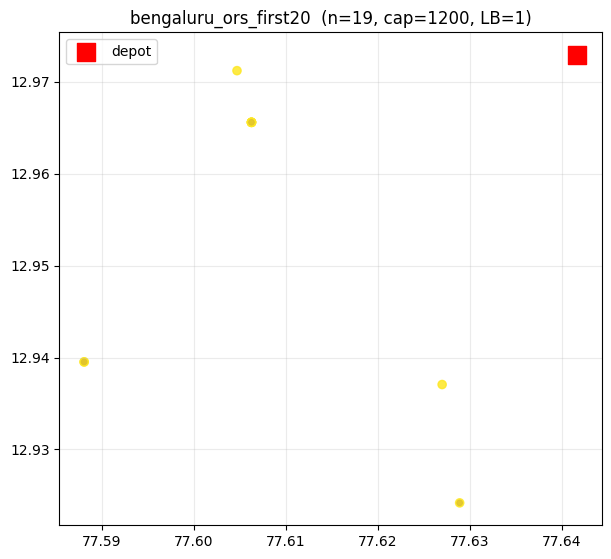

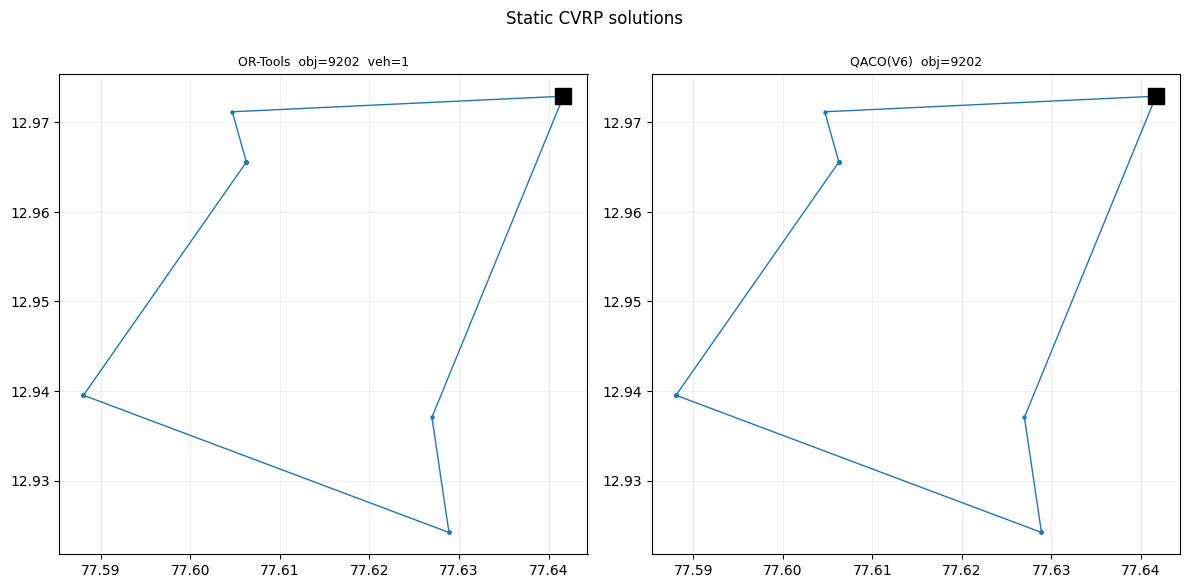

method                          objective    distance  veh    gap%   time s
V1 Classical ACO                   9202.2     25740.2    1    0.00      0.2
V6 Full QACO (static)              9202.2     25740.2    1    0.00      0.0
V8 Classical fusion + LS           9202.2     25740.2    1    0.00      0.0
Google OR-Tools (GLS)              9202.2     25740.2    1    0.00      5.0


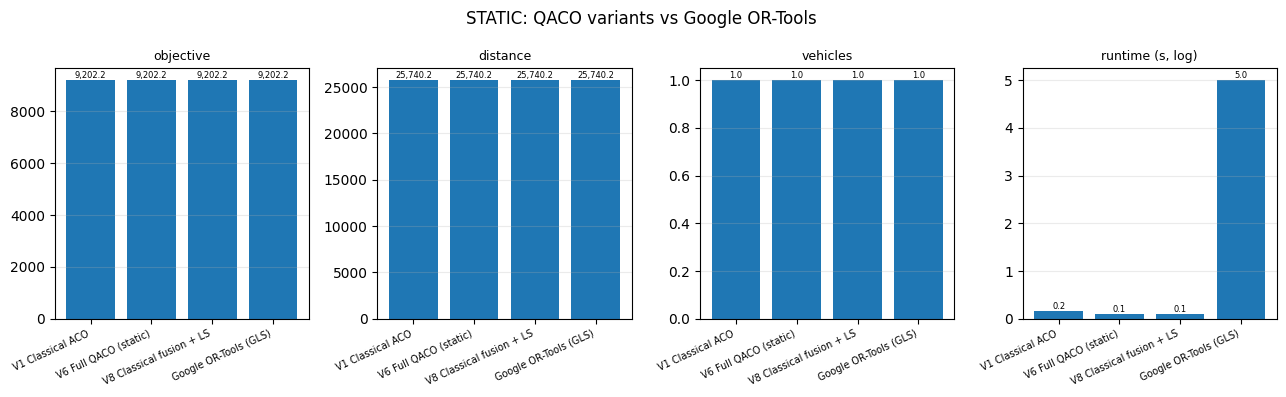

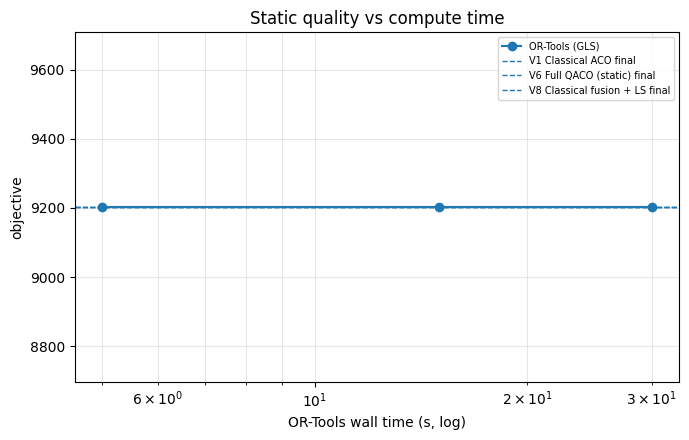

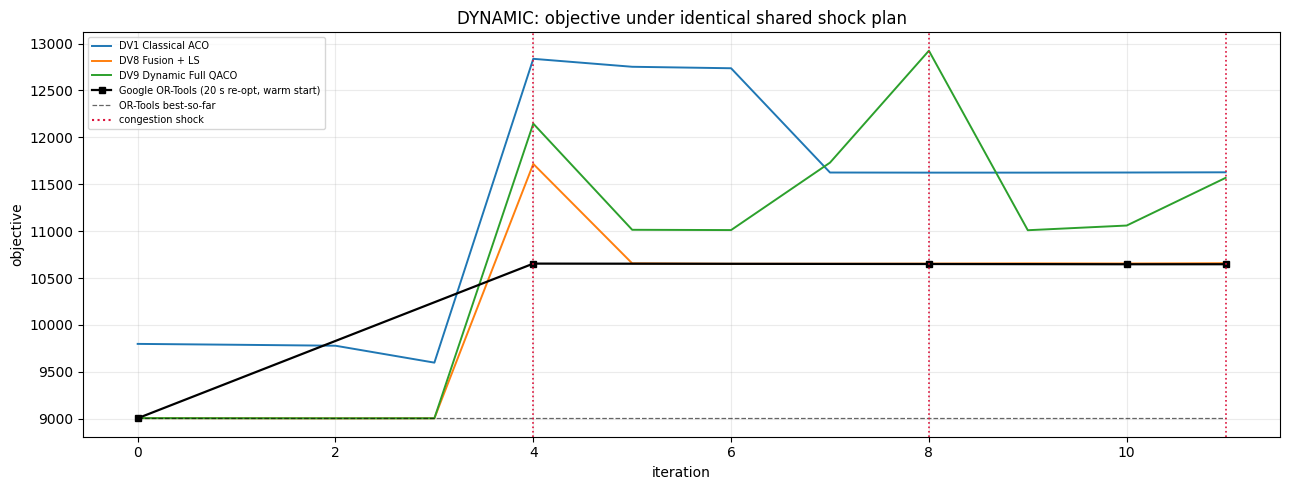

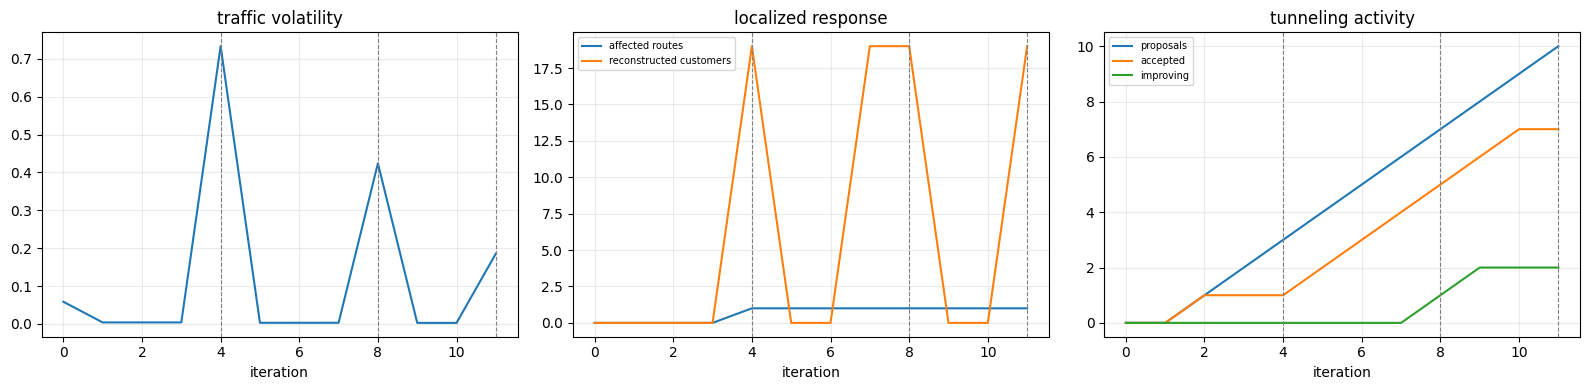

recovery iterations after shock:
4 {'DV9 QACO': 2.0, 'DV1 Classical ACO': 3.0, 'DV8 Fusion + LS': 2.0, 'DV9 Dynamic Full QACO': 2.0, 'OR-Tools': 6}
8 {'DV9 QACO': 2.0, 'DV1 Classical ACO': 0.0, 'DV8 Fusion + LS': 0.0, 'DV9 Dynamic Full QACO': 2.0, 'OR-Tools': 2}
11 {'DV9 QACO': nan, 'DV1 Classical ACO': nan, 'DV8 Fusion + LS': nan, 'DV9 Dynamic Full QACO': nan}


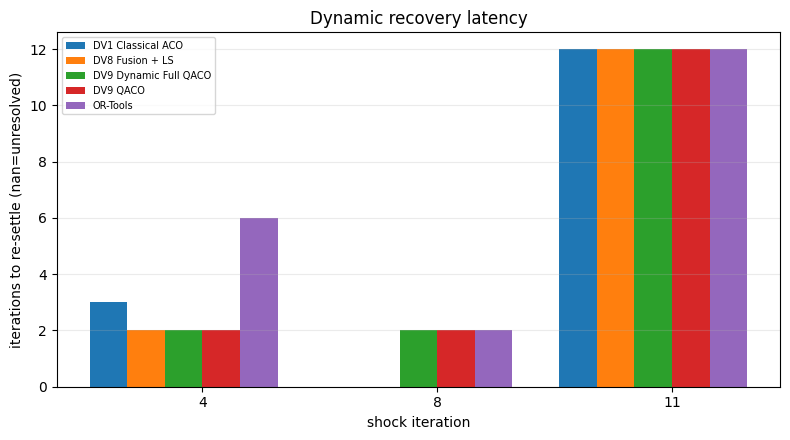

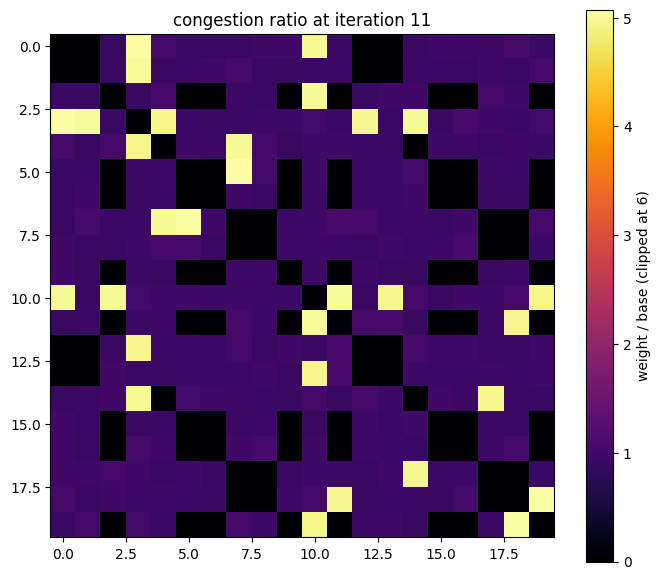

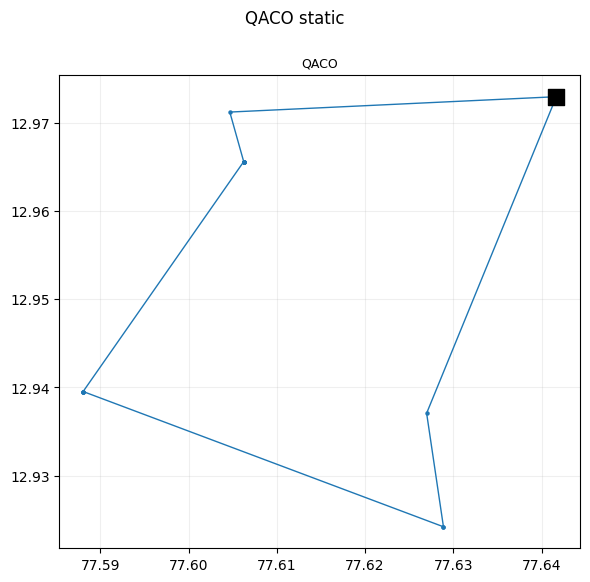

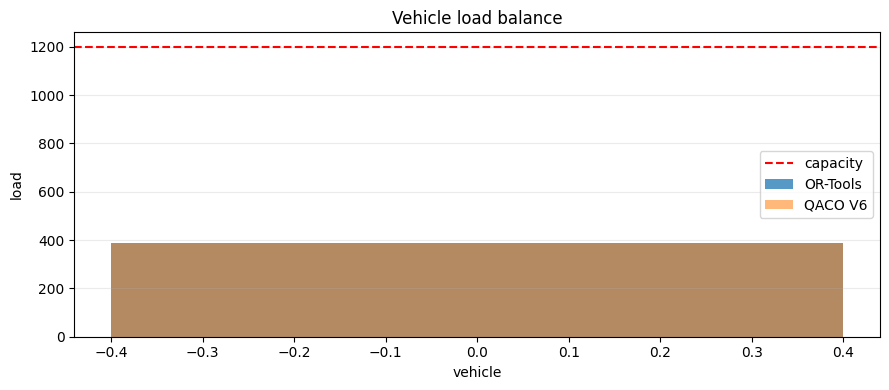

In [ ]:
if RUN_LEGACY_BENCHMARKS:
    def plot_instance(problem, title='Instance'):
        c, d = problem.coords, problem.demand
        plt.figure(figsize=(7, 7))
        plt.scatter(c[1:, 0], c[1:, 1], s=8 + d[1:] * 0.9, c=d[1:], cmap='viridis', alpha=.85)
        plt.scatter(*c[0], marker='s', s=180, c='red', zorder=5, label='depot')
        plt.gca().set_aspect('equal'); plt.legend(); plt.grid(alpha=.25); plt.title(title); plt.show()

    def plot_solutions(problem, sols, titles, suptitle='Routes', cmap='tab20'):
        fig, ax = plt.subplots(1, len(sols), figsize=(6 * len(sols), 6))
        ax = np.atleast_1d(ax)
        for a, sol, t in zip(ax, sols, titles):
            cols = plt.get_cmap(cmap)(np.linspace(0, 1, max(len(sol), 1)))
            for k, r in enumerate(sol):
                p = problem.coords[np.asarray(r)]
                a.plot(p[:, 0], p[:, 1], '-o', ms=2.2, lw=1.0, color=cols[k % len(cols)])
            a.scatter(*problem.coords[0], marker='s', s=140, c='k', zorder=5)
            a.set_aspect('equal'); a.set_title(t, fontsize=9); a.grid(alpha=.2)
        plt.suptitle(suptitle); plt.tight_layout(); plt.show()

    def plot_bars(labels, series, names, title, log=False, figsize=(13, 4)):
        fig, ax = plt.subplots(1, len(series), figsize=figsize)
        ax = np.atleast_1d(ax)
        for a, vals, nm in zip(ax, series, names):
            a.bar(range(len(labels)), vals, color='tab:blue')
            a.set_xticks(range(len(labels))); a.set_xticklabels(labels, rotation=25, ha='right', fontsize=7)
            a.set_title(nm, fontsize=9); a.grid(alpha=.25, axis='y')
            if log: a.set_yscale('log')
            for i, v in enumerate(vals): a.text(i, v, f'{v:,.1f}', ha='center', va='bottom', fontsize=6)
        plt.suptitle(title); plt.tight_layout(); plt.show()

    # ---------- 1. instance ----------
    plot_instance(DynamicVRP(CFG), f"{INSTANCE['name']}  (n={len(INSTANCE['coords'])-1}, "
                                   f"cap={INSTANCE['capacity']:.0f}, LB={LB})")

    # ---------- 2. static routes: OR-Tools vs QACO ----------
    plot_solutions(static_world,
                   [ORT_SOLUTION_STATIC, QACO_STATIC_BEST_SOLUTIONS['V6 Full QACO (static)']],
                   [f"OR-Tools  obj={ORT_BEST['objective']:.0f}  veh={ORT_BEST['vehicles']:.0f}",
                    f"QACO(V6)  obj={QACO_BEST_STATIC['V6 Full QACO (static)']:.0f}"],
                   'Static CVRP solutions')

    # ---------- 3. static comparison table + bars ----------
    rows = []
    for n in QACO_STATIC:
        r = min(QACO_STATIC[n], key=lambda x: x['objective'])
        rows.append({'method': n, 'objective': r['objective'], 'distance': r['distance'],
                     'vehicles': r['vehicles'], 'violations': r['violations'],
                     'runtime_s': r['runtime_s']})
    rows.append({'method': 'Google OR-Tools (GLS)', 'objective': ORT_BEST['objective'],
                 'distance': ORT_BEST['distance'], 'vehicles': ORT_BEST['vehicles'],
                 'violations': ORT_BEST['violations'], 'runtime_s': ORT_BEST['wall_s']})
    print(f"{'method':28s} {'objective':>12s} {'distance':>11s} {'veh':>4s} {'gap%':>7s} {'time s':>8s}")
    for x in rows:
        gap = 100 * (x['objective'] - ORT_BEST['objective']) / ORT_BEST['objective']
        print(f"{x['method']:28s} {x['objective']:12.1f} {x['distance']:11.1f} "
              f"{x['vehicles']:4.0f} {gap:7.2f} {x['runtime_s']:8.1f}")

    L = [x['method'] for x in rows]
    plot_bars(L, [[x['objective'] for x in rows], [x['distance'] for x in rows],
                  [x['vehicles'] for x in rows], [max(x['runtime_s'], .1) for x in rows]],
              ['objective', 'distance', 'vehicles', 'runtime (s, log)'],
              'STATIC: QACO variants vs Google OR-Tools', log=False)

    # ---------- 4. OR-Tools time/quality curve vs QACO ----------
    plt.figure(figsize=(7, 4.5))
    plt.plot([r['wall_s'] for r in ORT_STATIC], [r['objective'] for r in ORT_STATIC],
             'o-', label='OR-Tools (GLS)')
    for n, v in QACO_BEST_STATIC.items():
        plt.axhline(v, ls='--', lw=1, label=f'{n} final')
    plt.xscale('log'); plt.xlabel('OR-Tools wall time (s, log)'); plt.ylabel('objective')
    plt.title('Static quality vs compute time'); plt.grid(alpha=.3, which='both'); plt.legend(fontsize=7)
    plt.tight_layout(); plt.show()

    # ---------- 5. dynamic objective trajectories ----------
    plt.figure(figsize=(13, 5))
    for n, rec in QACO_DYNAMIC.items():
        plt.plot([r['iteration'] for r in rec], [r['objective'] for r in rec], label=n, lw=1.4)
    plt.plot([r['iteration'] for r in ORT_DYNAMIC], [r['objective'] for r in ORT_DYNAMIC],
             'ks-', ms=5, lw=1.6, label='Google OR-Tools (20 s re-opt, warm start)')
    plt.plot([r['iteration'] for r in ORT_DYNAMIC], [r.get('best_objective', np.nan) for r in ORT_DYNAMIC],
             'k--', lw=.9, alpha=.6, label='OR-Tools best-so-far')
    for it in PLAN: plt.axvline(it, color='crimson', ls=':', lw=1.2)
    plt.plot([], [], 'crimson', ls=':', label='congestion shock')
    plt.xlabel('iteration'); plt.ylabel('objective'); plt.grid(alpha=.25)
    plt.title('DYNAMIC: objective under identical shared shock plan'); plt.legend(fontsize=7)
    plt.tight_layout(); plt.show()

    # ---------- 6. traffic volatility / affected routes / tunneling ----------
    dyn = QACO_DYNAMIC['DV9 Dynamic Full QACO']
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot([r['volatility'] for r in dyn]); ax[0].set_title('traffic volatility')
    ax[1].plot([r['affected_routes'] for r in dyn], label='affected routes')
    ax[1].plot([r['reconstructed_customers'] for r in dyn], label='reconstructed customers')
    ax[1].legend(fontsize=7); ax[1].set_title('localized response')
    ax[2].plot([r['tunneling_events'] for r in dyn], label='proposals')
    ax[2].plot([r['successful_tunnels'] for r in dyn], label='accepted')
    ax[2].plot([r['improving_tunnels'] for r in dyn], label='improving'); ax[2].legend(fontsize=7)
    ax[2].set_title('tunneling activity')
    for a in ax:
        for it in PLAN: a.axvline(it, color='gray', ls='--', lw=.8)
        a.set_xlabel('iteration'); a.grid(alpha=.25)
    plt.tight_layout(); plt.show()

    # ---------- 7. recovery speed after each shock ----------
    def recovery_after_shock(
        records,
        shock,
        key='objective',
        settle_frac=0.2,
        window=12
    ):
        if shock >= len(records):
            return float('nan')

        post = records[
            shock:min(shock + window, len(records))
        ]

        if len(post) < 3:
            return float('nan')

        peak = max(
            record[key]
            for record in post[:min(3, len(post))]
        )

        adapted = float(np.median([
            record[key]
            for record in post[max(1, len(post) // 2):]
        ]))

        if peak <= adapted:
            return 0.0

        target = adapted + settle_frac * (peak - adapted)

        for record in post:
            if (
                record['iteration'] >= shock + 2
                and record[key] <= target
            ):
                return float(record['iteration'] - shock)

        return float('nan')


    rec_tab = {}

    for shock in sorted(PLAN):
        rec_tab[shock] = {
            'DV9 QACO': recovery_after_shock(
                dyn,
                shock,
                key='objective',
                window=12
            )
        }

        for name, records in QACO_DYNAMIC.items():
            rec_tab[shock][name] = recovery_after_shock(
                records,
                shock,
                key='objective',
                window=12
            )

        post = [
            record
            for record in ORT_DYNAMIC
            if shock <= record['iteration'] <= shock + 12
        ]

        if len(post) >= 2:
            peak = max(
                record['objective']
                for record in post[:2]
            )

            adapted = post[-1]['objective']
            target = adapted + 0.2 * (peak - adapted)

            rec_tab[shock]['OR-Tools'] = next(
                (
                    record['iteration'] - shock
                    for record in post
                    if record['objective'] <= target
                ),
                np.nan
            )


    print('recovery iterations after shock:')

    for shock, values in rec_tab.items():
        print(shock, values)


    labels = [str(shock) for shock in rec_tab]

    methods = sorted({
        method
        for values in rec_tab.values()
        for method in values
    })

    plt.figure(figsize=(8, 4.5))

    bar_width = 0.8 / max(len(methods), 1)

    for index, method in enumerate(methods):
        values = [
            np.nan_to_num(
                rec_tab[shock].get(method, np.nan),
                nan=12.0
            )
            for shock in rec_tab
        ]

        plt.bar(
            [
                j + index * bar_width
                for j in range(len(labels))
            ],
            values,
            bar_width,
            label=method
        )

    plt.xticks(
        [
            j + bar_width * len(methods) / 2
            for j in range(len(labels))
        ],
        labels
    )

    plt.xlabel('shock iteration')
    plt.ylabel('iterations to re-settle (nan=unresolved)')
    plt.title('Dynamic recovery latency')
    plt.grid(alpha=0.25, axis='y')
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    # ---------- 8. congestion heatmap at a shock ----------
    W, _ = traffic_replay({**CFG, 'seed': 17}, max(PLAN) + 1, {max(PLAN)})[max(PLAN)]
    plt.figure(figsize=(7, 6))
    plt.imshow(np.minimum(W / np.maximum(static_world.base, 1e-9), 6), cmap='inferno')
    plt.colorbar(label='weight / base (clipped at 6)')
    plt.title(f'congestion ratio at iteration {max(PLAN)}'); plt.tight_layout(); plt.show()

    # ---------- 9. load balance / fleet usage ----------
    def loads(problem, sol): return [problem.demand[np.asarray(r[1:-1], int)].sum() for r in sol]
    plot_solutions(static_world, [QACO_STATIC_BEST_SOLUTIONS['V6 Full QACO (static)']], ['QACO'], 'QACO static')
    plt.figure(figsize=(9, 4))
    plt.bar(range(len(loads(static_world, ORT_SOLUTION_STATIC))),
            loads(static_world, ORT_SOLUTION_STATIC), alpha=.75, label='OR-Tools')
    plt.bar(range(len(loads(static_world, QACO_STATIC_BEST_SOLUTIONS['V6 Full QACO (static)']))),
            loads(static_world, QACO_STATIC_BEST_SOLUTIONS['V6 Full QACO (static)']), alpha=.55, label='QACO V6')
    plt.axhline(float(CFG['capacity']), color='r', ls='--', label='capacity')
    plt.xlabel('vehicle'); plt.ylabel('load'); plt.title('Vehicle load balance')
    plt.grid(alpha=.25, axis='y'); plt.legend(); plt.tight_layout(); plt.show()

## 6. Rigorous ablations, classical interference control, and frozen empirical reference

The eight requested variants use identical budgets and repeated seeds. `Classical traffic fusion control` has the same historical/traffic scores but combines them as a weighted scalar sum. Its comparison with interference isolates whether the cross term changes behavior. The separate high-budget reference is computed before variant evaluation and is labeled empirical.

In [ ]:
if RUN_LEGACY_BENCHMARKS:
    STATIC_VARIANTS = {
        'V1 Classical ACO': {},
        'V6 Full QACO weak LS': {
            'interference_on': True,
            'tunneling_on': True,
            'local_search_on': True,
            'adaptive_on': True
        },
        'V8 Classical fusion + LS': {
            'classical_fusion_control': True,
            'adaptive_on': True,
            'local_search_on': True
        },
    }

    DYNAMIC_VARIANTS = {}

    for name, flags in STATIC_VARIANTS.items():
        dynamic_name = name.replace('V', 'DV')
        DYNAMIC_VARIANTS[dynamic_name] = {
            **flags,
            'dynamic_on': True,
            'partial_reconstruct_on': False,
        }
    DYNAMIC_VARIANTS = {
        name: DYNAMIC_VARIANTS[name]
        for name in ('DV1 Classical ACO', 'DV8 Classical fusion + LS')
    }

    DYNAMIC_VARIANTS['DV9 Dynamic Full QACO'] = {
        'interference_on': True,
        'tunneling_on': True,
        'local_search_on': True,
        'adaptive_on': True,
        'dynamic_on': True,
        'partial_reconstruct_on': True,
    }
    def run_experiments(
        variants: dict[str, dict[str, bool]],
        seeds: Sequence[int] = (17,)
    ) -> dict[str, list[list[dict[str, float]]]]:
        results = {name: [] for name in variants}

        for seed in seeds:
            for name, flags in variants.items():
                engine = DynamicQACO({**CFG, 'seed': seed}, flags)
                records, _, best = engine.run()
                results[name].append(records)

        return results

    # Freeze a lightweight empirical reference before comparisons (not a BKS/public optimum).
    # ------------------------------------------------------------------
    # Frozen empirical references
    # ------------------------------------------------------------------
    # These are not public BKS values. They are only internal reference
    # values for convergence diagnostics.
    # ------------------------------------------------------------------

    REFERENCE_CFG = {
        **CFG,
        'iterations': 12,
        'num_ants': 6,
        'seed': 101
    }

    reference_flags_static = {
        'interference_on': True,
        'tunneling_on': True,
        'local_search_on': True,
        'adaptive_on': True,
        'dynamic_on': False,
        'partial_reconstruct_on': False,
    }

    reference_records_static, _, _ = DynamicQACO(
        REFERENCE_CFG,
        reference_flags_static
    ).run()

    EMPIRICAL_REFERENCE_STATIC = float(
        min(
            r.get('pre_local_best', r['objective'])
            for r in reference_records_static
        )
    )

    print(f'Static empirical reference objective: {EMPIRICAL_REFERENCE_STATIC:.4f}')


    reference_flags_dynamic = {
        'interference_on': True,
        'tunneling_on': True,
        'local_search_on': True,
        'adaptive_on': True,
        'dynamic_on': True,
        'partial_reconstruct_on': True,
    }

    REFERENCE_CFG_DYNAMIC = {
        **REFERENCE_CFG,
        'seed': 102
    }

    reference_records_dynamic, _, _ = DynamicQACO(
        REFERENCE_CFG_DYNAMIC,
        reference_flags_dynamic
    ).run()

    EMPIRICAL_REFERENCE_DYNAMIC = float(
        min(
            r.get('pre_local_best', r['objective'])
            for r in reference_records_dynamic
        )
    )

    print(f'Dynamic empirical reference objective: {EMPIRICAL_REFERENCE_DYNAMIC:.4f}')
    # ------------------------------------------------------------------
    # Main experiments
    # ------------------------------------------------------------------

    static_results = run_experiments(
        STATIC_VARIANTS,
        seeds=(17,)
    )

    dynamic_results = run_experiments(
        DYNAMIC_VARIANTS,
        seeds=(17,)
    )


Static empirical reference objective: 9202.1973
Dynamic empirical reference objective: 9656.0742


In [ ]:
if RUN_LEGACY_BENCHMARKS:
    # ------------------------------------------------------------------
    # Diagnostic experiment: mechanism behavior without local search
    # ------------------------------------------------------------------
    # Use this first to verify that interference and tunneling are active.
    # If these variants all behave identically, the problem is still too
    # easy or the mechanisms are too weak.
    # ------------------------------------------------------------------

    MECHANISM_DIAGNOSTIC = {
        'M1 Classical': {},
        'M2 Interference': {
            'interference_on': True
        },
        'M4 Interference + Tunneling': {
            'interference_on': True,
            'tunneling_on': True,
            'adaptive_on': True
        },
    }

    mechanism_results = run_experiments(
        MECHANISM_DIAGNOSTIC,
        seeds=(17,)
    )

## 7. Metrics, dynamic recovery, and presentation-ready visualizations

The plots cover road geometry, traffic shocks, convergence, diversity, pheromone state, phases/cross terms, tunneling, affected routes, and recovery. Dynamic recovery is measured against the pre-shock incumbent under the new traffic, rather than using a circular minimum from the variants as a BKS.

Dynamic shock debug for DV9 Dynamic Full QACO
  shock 4: volatility_max=0.734, affected_max=1, reconstructed_max=19, rebuild_ms_max=2
  shock 8: volatility_max=0.424, affected_max=1, reconstructed_max=19, rebuild_ms_max=2
  shock 11: volatility_max=0.186, affected_max=1, reconstructed_max=19, rebuild_ms_max=2

STATIC EXPERIMENT SUMMARY
{'variant': 'V1 Classical ACO', 'objective_mean': 9202.197265625, 'objective_std': 0.0, 'pre_local_mean': 10302.1669921875, 'pre_local_std': 0.0, 'distance': 25740.23, 'travel_time': 2767.14013671875, 'congestion': 0.0, 'vehicles': 1.0, 'violations': 0.0, 'unique': 72.0, 'diversity': 0.7667736147615752, 'edge_diversity': 57.0, 'entropy': 0.7850573975853835, 'tunnel_proposals': 0.0, 'tunnel_feasible': 0.0, 'tunnel_success': 0.0, 'tunnel_improving': 0.0, 'affected_routes_final_mean': 0.0, 'affected_routes_all_mean': 0.0, 'affected_routes_max_mean': 0.0, 'reconstruction_events_mean': 0.0, 'reconstructed_customers_all_mean': 0.0, 'reconstruction_ms_sum_mean'

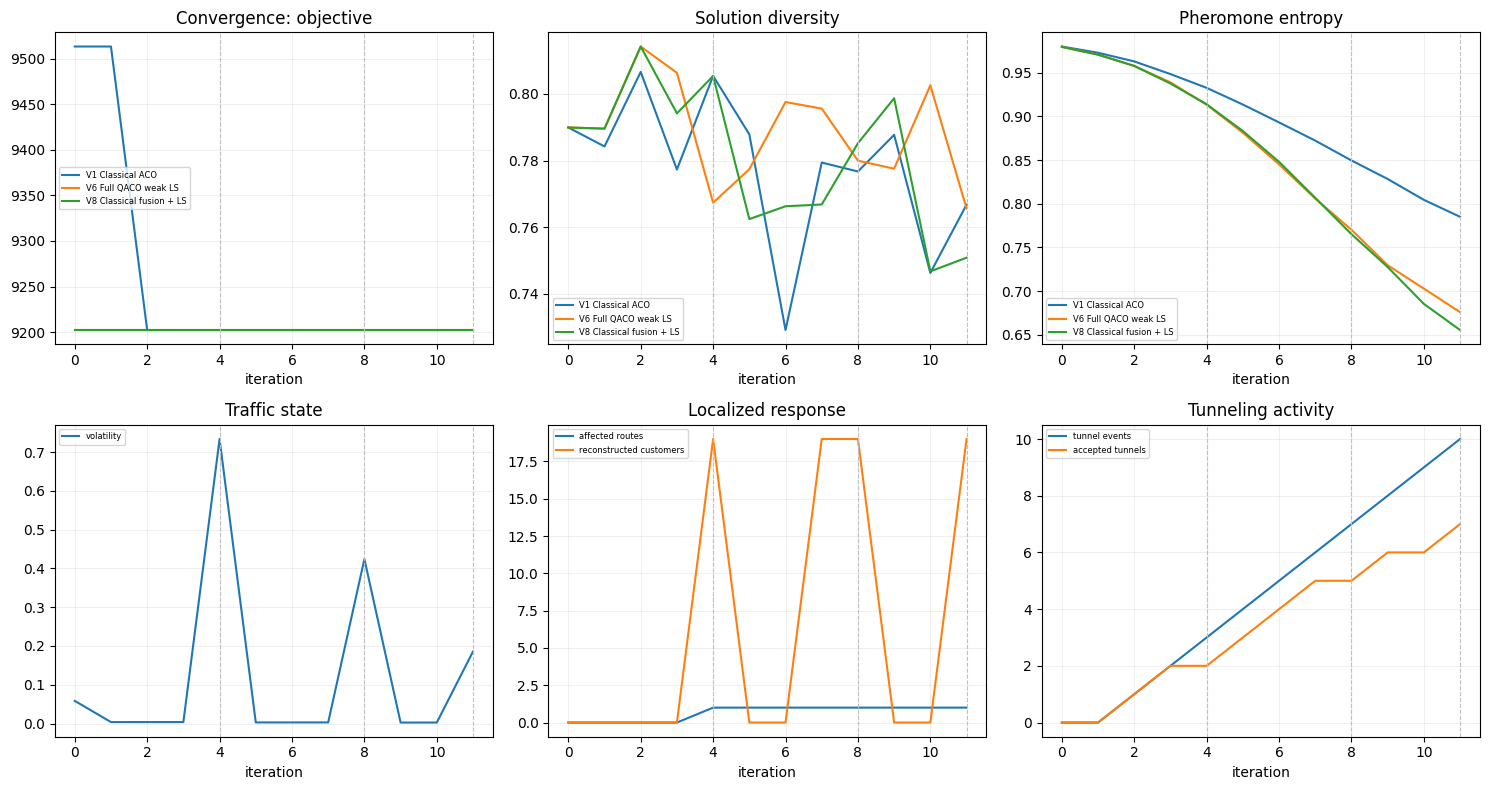

 audit run records: 12
logged interference decisions: 13518
Interference audit:
  number of logged decisions: 13518
  mean phase:                 0.1078
  positive cross terms:       10020
  negative cross terms:       546
  mean cross term:            0.022580


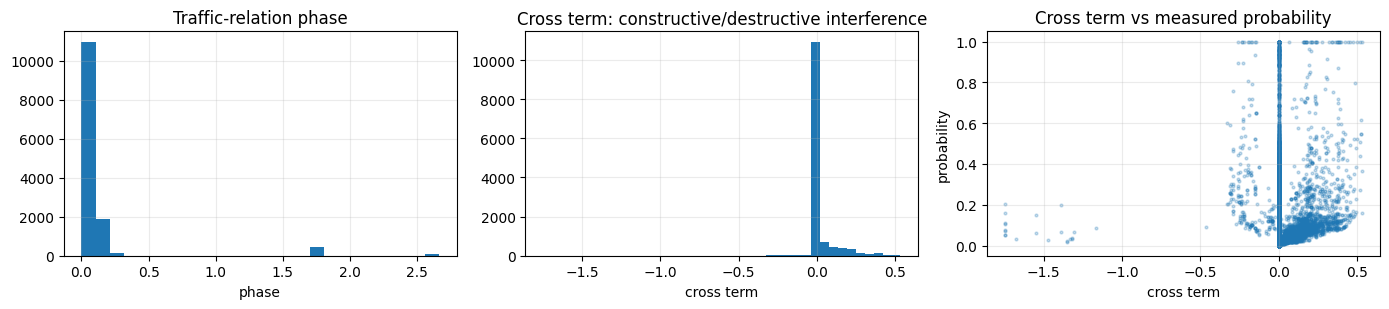

In [ ]:
if RUN_LEGACY_BENCHMARKS:
    def mean_series(runs:Sequence[Sequence[Mapping[str,float]]],key:str)->np.ndarray:return np.mean([[r[key] for r in run] for run in runs],axis=0)
    def recovery_after_shock(
        records: Sequence[Mapping[str, float]],
        shock: int,
        key: str = 'objective',
        settle_frac: float = 0.2,
        window: int = 45
    ) -> float:
        """
        Iterations until the selected metric settles to its adapted post-shock level.

        Parameters
        ----------
        records     : per-iteration record dicts from one run.
        shock       : shock iteration index.
        key         : metric to track, e.g. 'objective', 'pre_local_best',
                      'congestion', 'travel_time'. All are lower-is-better.
        settle_frac : fraction of the (peak - adapted) gap that counts as settled.
        window      : how many post-shock iterations to examine.
        """
        if shock >= len(records):
            return float('nan')

        post = records[shock: shock + min(window, len(records) - shock)]
        if len(post) < 3:
            return float('nan')

        # Spike level right after the shock.
        peak = max(r[key] for r in post[:min(3, len(post))])

        # Adapted level once the algorithm has had time to reroute.
        adapted_start = max(1, len(post) // 2)
        adapted = float(np.median([r[key] for r in post[adapted_start:]]))

        if peak <= adapted:
            return 0.0   # no visible spike, nothing to recover from

        target = adapted + settle_frac * (peak - adapted)

        for r in post:
            if r['iteration'] >= shock + 2 and r[key] <= target:
                return float(r['iteration'] - shock)

        return float('nan')

    def report(
        results: Mapping[str, Sequence[Sequence[Mapping[str, float]]]],
        reference_value: float
    ) -> list[dict[str, float | str]]:
        """
        Aggregate quality, exploration, tunneling, dynamic response, and convergence metrics.

        Important:
        - Objective and final-state metrics are taken from the final record.
        - Dynamic response metrics are aggregated over the whole run.
        """
        out = []

        reference_value = float(reference_value)
        target = reference_value * 1.05

        for name, runs in results.items():
            if len(runs) == 0:
                continue

            final = [run[-1] for run in runs if len(run) > 0]
            all_records = [x for run in runs for x in run]

            hits = []
            for run in runs:
                hit = next(
                    (
                        x['iteration']
                        for x in run
                        if x.get('pre_local_best', x['objective']) <= target
                    ),
                    np.nan
                )
                hits.append(hit)

            hits = np.asarray(hits, dtype=float)

            if hits.size > 0 and np.any(~np.isnan(hits)):
                iterations_to_target = float(np.nanmean(hits))
            else:
                iterations_to_target = float('nan')

            out.append({
                'variant': name,

                # Final objective metrics
                'objective_mean': float(np.mean([x['objective'] for x in final])),
                'objective_std': float(np.std([x['objective'] for x in final])),

                # Construction-phase metrics
                'pre_local_mean': float(np.mean([x.get('pre_local_best', x['objective']) for x in final])),
                'pre_local_std': float(np.std([x.get('pre_local_best', x['objective']) for x in final])),

                # Final route properties
                'distance': float(np.mean([x['distance'] for x in final])),
                'travel_time': float(np.mean([x['travel_time'] for x in final])),
                'congestion': float(np.mean([x['congestion'] for x in final])),
                'vehicles': float(np.mean([x['vehicles'] for x in final])),
                'violations': float(np.mean([x['violations'] for x in final])),

                # Final exploration metrics
                'unique': float(np.mean([x['unique_solutions'] for x in final])),
                'diversity': float(np.mean([x['diversity'] for x in final])),
                'edge_diversity': float(np.mean([x.get('edge_diversity', 0.0) for x in final])),
                'entropy': float(np.mean([x['entropy'] for x in final])),

                # Tunneling metrics are cumulative in the final record
                'tunnel_proposals': float(np.mean([x.get('tunneling_events', 0.0) for x in final])),
                'tunnel_feasible': float(np.mean([x.get('tunnel_feasible', 0.0) for x in final])),
                'tunnel_success': float(np.mean([x.get('successful_tunnels', 0.0) for x in final])),
                'tunnel_improving': float(np.mean([x.get('improving_tunnels', 0.0) for x in final])),

                # Dynamic response metrics over entire run
                'affected_routes_final_mean': float(np.mean([x.get('affected_routes', 0.0) for x in final])),
                'affected_routes_all_mean': float(np.mean([x.get('affected_routes', 0.0) for x in all_records])),
                'affected_routes_max_mean': float(np.mean([
                    max((r.get('affected_routes', 0.0) for r in run), default=0.0)
                    for run in runs
                ])),

                'reconstruction_events_mean': float(np.mean([
                    sum(1 for r in run if r.get('reconstruction_ms', 0.0) > 0)
                    for run in runs
                ])),

                'reconstructed_customers_all_mean': float(np.mean([
                    x.get('reconstructed_customers', 0.0)
                    for x in all_records
                ])),

                'reconstruction_ms_sum_mean': float(np.mean([
                    sum(r.get('reconstruction_ms', 0.0) for r in run)
                    for run in runs
                ])),

                # Convergence metric
                'iterations_to_empirical_target': iterations_to_target,
            })

        return out
    static_summary = report(
        static_results,
        EMPIRICAL_REFERENCE_STATIC
    )

    dynamic_summary = report(
        dynamic_results,
        EMPIRICAL_REFERENCE_DYNAMIC
    )

    def dynamic_shock_debug(
        results: Mapping[str, Sequence[Sequence[Mapping[str, float]]]],
        variant_key: str
    ) -> None:
        if variant_key not in results:
            print(f'{variant_key} not found in results.')
            return

        run = results[variant_key][0]

        print(f'Dynamic shock debug for {variant_key}')

        shock_iterations = sorted(CFG['shock_iterations'])
        for shock_index, shock in enumerate(shock_iterations):
            if shock >= len(run):
                print(f'  shock {shock}: outside run length')
                continue

            next_shock = (shock_iterations[shock_index + 1]
                          if shock_index + 1 < len(shock_iterations)
                          else shock + 1)
            end = min(len(run), next_shock)
            window = run[shock:end]

            affected_max = max(r.get('affected_routes', 0.0) for r in window)
            reconstructed_max = max(r.get('reconstructed_customers', 0.0) for r in window)
            rebuild_ms_max = max(r.get('reconstruction_ms', 0.0) for r in window)
            volatility_max = max(r.get('volatility', 0.0) for r in window)

            print(
                f'  shock {shock}: '
                f'volatility_max={volatility_max:.3f}, '
                f'affected_max={affected_max:.0f}, '
                f'reconstructed_max={reconstructed_max:.0f}, '
                f'rebuild_ms_max={rebuild_ms_max:.0f}'
            )

    dynamic_shock_debug(dynamic_results, 'DV9 Dynamic Full QACO')

    mechanism_summary = report(
        mechanism_results,
        EMPIRICAL_REFERENCE_STATIC
    )

    print('\nSTATIC EXPERIMENT SUMMARY')
    for row in static_summary:
        print(row)

    print('\nDYNAMIC EXPERIMENT SUMMARY')
    for row in dynamic_summary:
        print(row)

    print('\nMECHANISM DIAGNOSTIC SUMMARY')
    for row in mechanism_summary:
        print(row)


    fig,ax=plt.subplots(2,3,figsize=(15,8));
    for name,runs in static_results.items():
        if name.startswith('V') or name=='Classical traffic fusion control':
            x=np.arange(len(runs[0])); ax[0,0].plot(x,mean_series(runs,'objective'),label=name); ax[0,1].plot(x,mean_series(runs,'diversity'),label=name); ax[0,2].plot(x,mean_series(runs,'entropy'),label=name)
    dynamic=dynamic_results['DV9 Dynamic Full QACO'][0]
    ax[1,0].plot([r['volatility'] for r in dynamic],label='volatility'); ax[1,1].plot([r['affected_routes'] for r in dynamic],label='affected routes'); ax[1,1].plot([r['reconstructed_customers'] for r in dynamic],label='reconstructed customers'); ax[1,2].plot([r['tunneling_events'] for r in dynamic],label='tunnel events'); ax[1,2].plot([r['successful_tunnels'] for r in dynamic],label='accepted tunnels')
    for a,title in zip(ax.flat,['Convergence: objective','Solution diversity','Pheromone entropy','Traffic state','Localized response','Tunneling activity']):
        for shock in CFG['shock_iterations']: a.axvline(shock,color='0.75',ls='--',lw=.8)
        a.set_title(title); a.set_xlabel('iteration'); a.grid(alpha=.2); a.legend(fontsize=6)
    plt.tight_layout();plt.show()

    # Interference audit: phases, constructive/destructive cross terms, and measured probabilities.
    audit_cfg = {
        **CFG,
        'iterations': 12,
        'num_ants': 6,
        'seed': 17,
        'log_interference': True
    }

    audit_flags = {
        'interference_on': True,
        'dynamic_on': True,
        'adaptive_on': True
    }

    audit_runner = DynamicQACO(audit_cfg, audit_flags)

    # Override any stale CFG/class state in the current Colab session.
    audit_runner.flags['interference_on'] = True
    audit_runner.interference.log_enabled = True
    audit_runner.interference.log = []

    audit_records, audit, audit_best = audit_runner.run()

    # Use the engine's live log as the authoritative source.
    audit = audit_runner.interference.log

    print(f' audit run records: {len(audit_records)}')
    print(f'logged interference decisions: {len(audit)}')

    if not audit:
        raise RuntimeError(
            'No interference decisions were logged. '
            'Rerun the cell defining DynamicQACO and InterferenceEngine, '
            'then rerun this audit block.'
        )

    cross = np.asarray([
        item['cross_term']
        for item in audit
    ])

    phase = np.asarray([
        item['phase']
        for item in audit
    ])

    prob = np.asarray([
        item['probability']
        for item in audit
    ])

    print('Interference audit:')
    print(f'  number of logged decisions: {len(audit)}')
    print(f'  mean phase:                 {np.mean(phase):.4f}')
    print(f'  positive cross terms:       {np.sum(cross > 0)}')
    print(f'  negative cross terms:       {np.sum(cross < 0)}')
    print(f'  mean cross term:            {np.mean(cross):.6f}')

    fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))

    ax[0].hist(phase, bins=25)
    ax[0].set_title('Traffic-relation phase')
    ax[0].set_xlabel('phase')
    ax[0].grid(alpha=0.25)

    ax[1].hist(cross, bins=40)
    ax[1].set_title('Cross term: constructive/destructive interference')
    ax[1].set_xlabel('cross term')
    ax[1].grid(alpha=0.25)

    ax[2].scatter(cross, prob, s=4, alpha=0.25)
    ax[2].set_title('Cross term vs measured probability')
    ax[2].set_xlabel('cross term')
    ax[2].set_ylabel('probability')
    ax[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

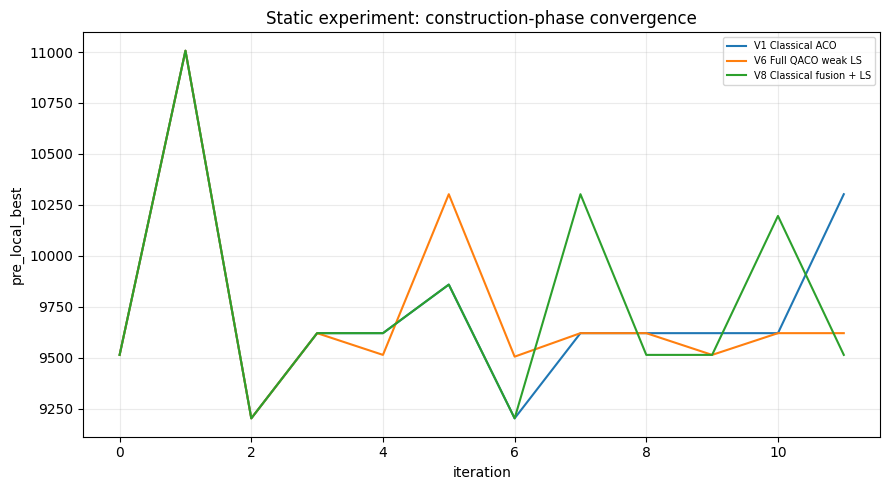

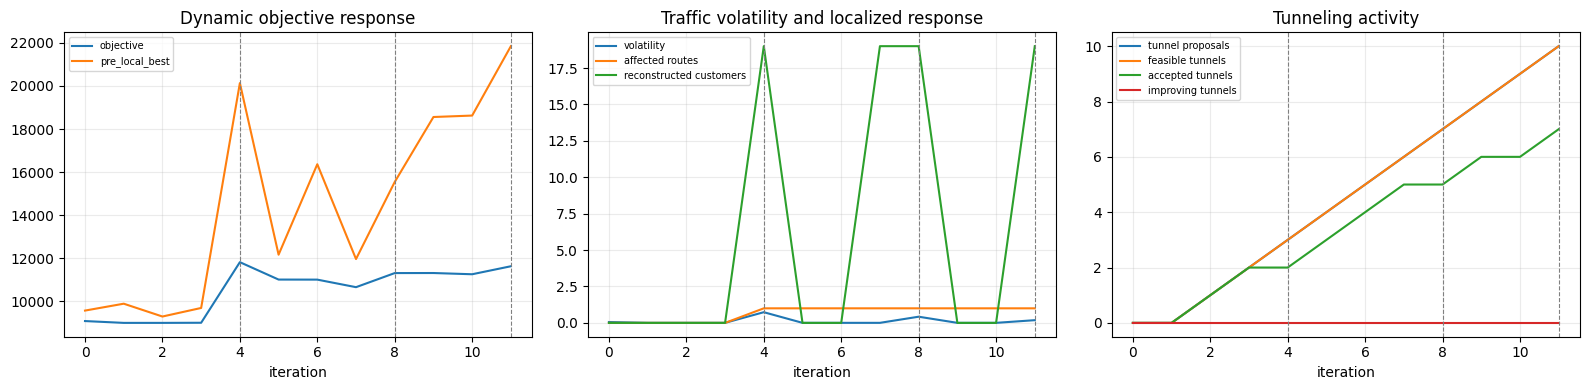

In [ ]:
if RUN_LEGACY_BENCHMARKS:
    plt.figure(figsize=(9, 5))

    for name, runs in static_results.items():
        if len(runs) == 0:
            continue

        x = np.arange(len(runs[0]))
        y = mean_series(runs, 'pre_local_best')

        plt.plot(x, y, label=name)

    plt.title('Static experiment: construction-phase convergence')
    plt.xlabel('iteration')
    plt.ylabel('pre_local_best')
    plt.grid(alpha=0.25)
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


    dynamic_full_name = 'DV9 Dynamic Full QACO'

    if dynamic_full_name not in dynamic_results:
        candidates = [k for k in dynamic_results.keys() if 'Full QACO' in k]
        if len(candidates) == 0:
            raise KeyError('Could not find the dynamic full QACO variant in dynamic_results.')
        dynamic_full_name = candidates[0]

    dynamic_run = dynamic_results[dynamic_full_name][0]

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))

    ax[0].plot([r['objective'] for r in dynamic_run], label='objective')
    ax[0].plot([r.get('pre_local_best', r['objective']) for r in dynamic_run], label='pre_local_best')
    ax[0].set_title('Dynamic objective response')
    ax[0].set_xlabel('iteration')
    ax[0].grid(alpha=0.25)
    ax[0].legend(fontsize=7)

    ax[1].plot([r['volatility'] for r in dynamic_run], label='volatility')
    ax[1].plot([r['affected_routes'] for r in dynamic_run], label='affected routes')
    ax[1].plot([r['reconstructed_customers'] for r in dynamic_run], label='reconstructed customers')
    ax[1].set_title('Traffic volatility and localized response')
    ax[1].set_xlabel('iteration')
    ax[1].grid(alpha=0.25)
    ax[1].legend(fontsize=7)

    ax[2].plot([r['tunneling_events'] for r in dynamic_run], label='tunnel proposals')
    ax[2].plot([r['tunnel_feasible'] for r in dynamic_run], label='feasible tunnels')
    ax[2].plot([r['successful_tunnels'] for r in dynamic_run], label='accepted tunnels')
    ax[2].plot([r['improving_tunnels'] for r in dynamic_run], label='improving tunnels')
    ax[2].set_title('Tunneling activity')
    ax[2].set_xlabel('iteration')
    ax[2].grid(alpha=0.25)
    ax[2].legend(fontsize=7)

    for a in ax:
        for shock in CFG['shock_iterations']:
            a.axvline(shock, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    plt.show()

In [ ]:
if RUN_LEGACY_BENCHMARKS:
    def recovery_after_shock(records, shock, key='objective', settle_frac=0.2, window=12):
        if shock >= len(records):
            return float('nan')
        post = records[shock:shock + min(window, len(records) - shock)]
        if len(post) < 3:
            return float('nan')
        peak = max(r[key] for r in post[:min(3, len(post))])
        adapted = float(np.median([r[key] for r in post[max(1, len(post) // 2):]]))
        if peak <= adapted:
            return 0.0
        target = adapted + settle_frac * (peak - adapted)
        for r in post:
            if r['iteration'] >= shock + 2 and r[key] <= target:
                return float(r['iteration'] - shock)
        return float('nan')

    recovery_table = {}

    for shock in CFG['shock_iterations']:
        recovery_table[shock] = recovery_after_shock(
            dynamic_run,
            shock,
            key='objective'
        )

    print('Dynamic Full QACO recovery iterations after each shock:')
    print(recovery_table)

Dynamic Full QACO recovery iterations after each shock:
{4: 2.0, 8: 0.0, 11: nan}


## 8. Automated validation checklist

The assertions are compact executable checks for the implementation mechanisms. The original V1 notebook is verified outside this notebook by SHA-256 before and after V2 work; V2 itself tests traffic, multi-vehicle construction, amplitude cross terms, local improvement operators, tunneling acceptance, adaptation, partial reconstruction, repeated-seed ablations, and metrics. No claim of universal superiority is made; use benchmark data, calibrated parameters, and repeated independent studies for research conclusions.

In [ ]:
# ------------------------------------------------------------------
# Updated automated validation checklist
# ------------------------------------------------------------------

# 1. Dynamic traffic advances and shocks persist.
p = DynamicVRP(CFG)

shock_iter = int(CFG['shock_iterations'][0])

vol, delta = p.advance(shock_iter, dynamic=True)

assert vol >= 0.0
assert delta.shape == p.weight.shape
assert len(p.changed_edges) > 0, 'No changed edges after shock.'
assert len(p.active_shocks) > 0, 'active_shocks was not populated.'

# Advance one iteration later; shocks should persist because of shock_duration.
vol_next, delta_next = p.advance(shock_iter + 1, dynamic=True)

assert len(p.active_shocks) > 0, 'Shock did not persist for multiple iterations.'

# 2. Interference scores and phases are bounded.
state = QuantumAmplitudeState(len(p.demand))
engine = InterferenceEngine(p, state, CFG)

h, t, ph = engine.scores(0, [1, 2, 3], delta_next)

assert np.all(h >= 0)
assert np.all(ph >= 0)
assert np.all(ph <= np.pi)

# 3. Basic amplitude cross-term sanity.
ah = np.array([1 + 0j])
at = np.array([np.exp(1j * np.pi)])
demo_cross = 2 * np.real(np.conj(ah) * at)

assert demo_cross[0] < 0, 'Destructive demo cross term should be negative.'

# 4. Tunneling acceptance sanity.
# Create a temporary TunnelingOperator instance for testing the static method.
temp_tunneler_for_test = TunnelingOperator(p, np.random.default_rng(1))
assert temp_tunneler_for_test.tunnel_accept(
    2.0,
    1.0,
    1,
    10,
    0,
    0.0,
    CFG,
    np.random.default_rng(1)
), 'Improving tunneling candidate should be accepted.'

# 5. Adaptive controller returns bounded controls.
controls = AdaptiveController(CFG).controls(
    stagnation=99,
    diversity=0.0,
    volatility=1.0,
    ls_fail=9,
    adaptive=True
)

assert 0.0 <= controls['tunnel_p'] <= 1.0
assert controls['candidate_k'] >= int(CFG['candidate_k_min'])
assert controls['candidate_k'] <= int(CFG['candidate_k_max'])
assert controls['rho'] >= float(CFG['rho_min'])
assert controls['rho'] <= float(CFG['rho_max'])

# 6. Smoke run contains the new observables.
runner_cfg = {
    **CFG,
    'iterations': 8,
    'num_ants': 4,
    'seed': 17,
    'log_interference': True
}

runner_flags = {
    'interference_on': True,
    'local_search_on': True,
    'tunneling_on': True,
    'adaptive_on': True,
    'dynamic_on': True,
    'partial_reconstruct_on': True
}

runner = DynamicQACO(runner_cfg, runner_flags)

# Override stale settings in an already-running Colab kernel.
runner.flags['interference_on'] = True
runner.interference.log_enabled = True
runner.interference.log.clear()

smoke, _, _ = runner.run()

# Read the live engine log after the run.
audit = runner.interference.log

print(f'smoke records: {len(smoke)}')
print(f'interference records: {len(audit)}')

assert len(smoke) == 8, (
    'Smoke run did not produce the expected number of records.'
)

assert len(audit) > 0, (
    'Interference audit log is empty.'
)

assert all(
    record['violations'] == 0
    for record in smoke
), 'Smoke run produced infeasible solutions.'

assert all(
    'pre_local_best' in record
    for record in smoke
), 'Missing pre_local_best metric.'

assert all(
    'tunneling_events' in record
    for record in smoke
), 'Missing tunneling_events metric.'

assert all(
    'tunnel_feasible' in record
    for record in smoke
), 'Missing tunnel_feasible metric.'

assert all(
    'successful_tunnels' in record
    for record in smoke
), 'Missing successful_tunnels metric.'

assert all(
    'improving_tunnels' in record
    for record in smoke
), 'Missing improving_tunnels metric.'

assert all(
    'affected_routes' in record
    for record in smoke
), 'Missing affected_routes metric.'

assert all(
    'reconstruction_ms' in record
    for record in smoke
), 'Missing reconstruction_ms metric.'

print('Validation smoke run passed.')


smoke records: 8
interference records: 6395
Validation smoke run passed.


In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU is available. Device name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available.")

GPU is available. Device name: Tesla T4


## 8. Bridge-specific executable validation

These checks validate the join on the loaded ORS data: feature alignment,
one-time pheromone injection, exact cost units, directed 2-opt gains,
unchanged shock evolution on the same duration baseline, shock expiry,
final-state route coverage, tensor replay synchronization, and frozen GAT weights.

In [ ]:
def validate_bridge():
    assert np.array_equal(ors_graph.edge_attr.numpy(),
                          np.asarray(scaled_features[dst_nodes], dtype=np.float32))
    expected = np.maximum(GAT_ORS_PRIOR, 0.001)
    np.fill_diagonal(expected, 0)
    expected /= expected.sum(axis=1, keepdims=True) / (n_ors - 1)
    check = GATDynamicQACO(HYBRID_CFG, HYBRID_FLAGS)
    np.testing.assert_allclose(check.state.pheromone, expected)
    baseline = DynamicQACO(HYBRID_CFG, HYBRID_FLAGS)
    assert not np.allclose(check.state.pheromone, baseline.state.pheromone), 'GAT prior is uniform: inspect training.'

    # Source shock equations must produce identical weights on the ORS baseline.
    original = SourceDynamicVRP(HYBRID_CFG)
    original._base_t = check.p._base_t.clone()
    original.base = original._base_t.cpu().numpy().copy()
    original._weight_t = original._base_t.clone()
    original._previous_t = original._weight_t.clone()
    original.weight = original.base.copy(); original.previous = original.base.copy()
    preferred = [(0, 1), (1, 2), (2, 3)]
    first_shock = int(HYBRID_CFG['shock_iterations'][0])
    for it in range(first_shock + 2):
        vol_a, delta_a = original.advance(it, True, preferred)
        vol_b, delta_b = check.p.advance(it, True, preferred)
        np.testing.assert_allclose(original.weight, check.p.weight)
        np.testing.assert_allclose(delta_a, delta_b)
        assert np.isclose(vol_a, vol_b)
        assert original.active_shocks == check.p.active_shocks
    expiry = first_shock + int(HYBRID_CFG['shock_duration'])
    check.p.advance(expiry, True, preferred)
    assert not check.p.active_shocks
    C = (float(HYBRID_CFG['objective_distance']) * check.p.road_distances
         + float(HYBRID_CFG['objective_time']) * check.p.weight
         + float(HYBRID_CFG['objective_congestion']) * np.maximum(check.p.weight - check.p.base, 0))
    np.testing.assert_allclose(check.p.cost_matrix(), C, rtol=1e-6, atol=1e-3)
    check.p.weight = check.p.weight * 1.1
    check.p.invalidate()
    np.testing.assert_allclose(check.p._weight_t.cpu().numpy(), check.p.weight, rtol=1e-6)

    # Compare the directed shortcut with brute-force reversals on real costs.
    rng = np.random.default_rng(7)
    W = hybrid.p.cost_matrix()
    route_cost = lambda r: float(W[np.asarray(r[:-1]), np.asarray(r[1:])].sum())
    for _ in range(10):
        route = [0] + rng.permutation(np.arange(1, n_ors)).tolist() + [0]
        proposal, gain = hybrid.local._two_opt(W, route)
        brute = min([route_cost(route)] + [route_cost(route[:a] + route[a:b+1][::-1] + route[b+1:])
                    for a in range(1, len(route)-2) for b in range(a, len(route)-1)])
        assert np.isclose(route_cost(proposal), brute, rtol=1e-6, atol=0.1)
        assert np.isclose(route_cost(route) - route_cost(proposal), gain, rtol=1e-5, atol=0.1)
    visited = [i for r in hybrid_final_routes for i in r[1:-1]]
    assert sorted(visited) == list(range(1, n_ors))
    saved_weights = torch.load(ARTIFACT_DIR / 'gat_ors_global_model.pt', map_location='cpu', weights_only=True)
    assert all(torch.equal(value.cpu(), saved_weights[key]) for key, value in global_model.state_dict().items())
    assert GATDynamicQACO.run is DynamicQACO.run
    assert GATDynamicQACO._build is DynamicQACO._build
    assert hybrid_metrics['affected_routes'].max() > 0
    assert hybrid_metrics['reconstructed_customers'].max() > 0
    assert hybrid_metrics['tunneling_events'].iloc[-1] > 0
    print('Bridge validation passed on the actual Bengaluru ORS matrices.')

validate_bridge()


Bridge validation passed on the actual Bengaluru ORS matrices.


## 9. Source preservation and interpretation

The original notebooks are never overwritten. All GAT model/training functions
and QACO interference/tunneling/controller/pheromone/reconstruction functions are
copied from the supplied files. The ORS adapter and prior initialization are
separate classes. Only the documented input, indexing, directed-cost, replay,
and output seams change behavior.

The existing mock-graph GAT training is intentionally preserved. Mapping that
model to road coordinates is a transfer assumption that requires held-out
validation before making performance claims. The ORS matrices are real service
responses; the traffic shocks and customer demands are the source's synthetic
experiment. No new shock generator or replacement GAT model is introduced.

The notebook uses classical quantum-inspired computation, as the source states.

| Source | Cell | Status | Adaptation |
|---|---:|---|---|
| GAT_ORS | 0 | adapted | Dataset path; environment/hidden key input; optional real-ORS cache. Geocoder function unchanged. |
| GAT_ORS | 1 | adapted | Optional real-ORS matrix cache; live request and diurnal synthesizer unchanged. |
| GAT_ORS | 2 | unchanged | — |
| GAT_ORS | 3 | adapted | Explicit notebook pip magic for portability. |
| GAT_ORS | 4 | adapted | Dataset path only. |
| GAT_ORS | 5 | unchanged | — |
| GAT_ORS | 6 | unchanged | — |
| GAT_ORS | 7 | unchanged | — |
| GAT_ORS | 8 | unchanged | — |
| GAT_ORS | 9 | unchanged | — |
| GAT_ORS | 10 | unchanged | — |
| Dynamic_Interference | 0 | unchanged | — |
| Dynamic_Interference | 1 | unchanged | — |
| Dynamic_Interference | 2 | unchanged | — |
| Dynamic_Interference | 4 | adapted | Replace only the 560.vrp loading/self-check tail with the Bengaluru instance; parser/generator/fleet helpers unchanged. |
| Dynamic_Interference | 5 | unchanged | — |
| Dynamic_Interference | 6 | unchanged | — |
| Dynamic_Interference | 7 | unchanged | — |
| Dynamic_Interference | 8 | unchanged | — |
| Dynamic_Interference | 9 | unchanged | — |
| Dynamic_Interference | 10 | unchanged | — |
| Dynamic_Interference | 11 | unchanged | — |
| Dynamic_Interference | 12 | unchanged | — |
| Dynamic_Interference | 13 | unchanged | — |
| Dynamic_Interference | 14 | unchanged | — |
| Dynamic_Interference | 15 | unchanged | — |
| Dynamic_Interference | 16 | unchanged | — |
| Dynamic_Interference | 17 | adapted | Two bridge hooks only: respect an explicit benchmark replay plan; expose final_solution without changing the original historical-best return. |
| Dynamic_Interference | 18 | unchanged | — |
| Dynamic_Interference | 19 | unchanged | — |
| Dynamic_Interference | 20 | adapted | Replace hard-coded 560-node diagnostic IDs with the current Bengaluru IDs. |
| Dynamic_Interference | 21 | adapted | Bound subsets to Bengaluru size, carry ORS node IDs, and restore Bengaluru rather than 560.vrp. |
| Dynamic_Interference | 22 | adapted | Optional execution guard; install the original OR-Tools version without uninstalling it first. |
| Dynamic_Interference | 23 | adapted | Optional execution guard only. |
| Dynamic_Interference | 24 | adapted | Optional execution guard only. |
| Dynamic_Interference | 25 | adapted | Optional execution guard only. |
| Dynamic_Interference | 26 | adapted | Optional execution guard; pass the shared shock plan into BENCH_CFG for the ORS replay bridge. |
| Dynamic_Interference | 27 | adapted | Optional execution guard only. |
| Dynamic_Interference | 28 | unchanged | Optional execution guard only. |
| Dynamic_Interference | 29 | adapted | Optional execution guard only. |
| Dynamic_Interference | 30 | adapted | Optional execution guard only. |
| Dynamic_Interference | 31 | unchanged | Optional execution guard only. |
| Dynamic_Interference | 32 | adapted | Optional execution guard only. |
| Dynamic_Interference | 33 | adapted | Optional execution guard only. |
| Dynamic_Interference | 34 | adapted | Optional execution guard only. |
| Dynamic_Interference | 35 | unchanged | — |
| Dynamic_Interference | 36 | unchanged | — |
| Dynamic_Interference | 37 | unchanged | — |
| Dynamic_Interference | 38 | unchanged | — |